In [20]:
import numpy as np
import matplotlib.pyplot as plt
from netCDF4 import Dataset
import datetime as dt
# from sklearn import preprocessing
import csv
from ICECAPS_support_functions import load_netcdf, load_raven_sleigh_data, load_netcdf, datetimes_to_seconds, interpolate_and_mask, get_simba_time_of_day
import glob
from cmcrameri import cm as cmr
from scipy import interpolate


import matplotlib.dates as mdates
myFmt = mdates.DateFormatter('%m-%d')

Replace this file with whatever new one Michael sends

In [21]:
# simba_filepath = '/psd3data/arctic/sledd/Raven_simba/'

simba_fname = 'firnprofile-combined-corrected.FINAL_FOR_REAL.v37.sled.level2.beta.15min.20240517-20240821_created_September_18_2025.nc'
simba_filepath = '/psd3data/arctic/sledd/Raven_simba/'


# simba_data = {}
varnames = ['temperature','initial_height','time','temperature_correction']
simba_data = load_netcdf(simba_filepath+simba_fname, varnames)

fstart_time = dt.datetime.strptime(simba_data['time_unit'], 'minutes since %Y-%m-%d')
simba_data['dates'] = np.asarray([fstart_time+dt.timedelta(minutes=int(m)) for m in simba_data['time']])

In [22]:
simba_temps = simba_data['temperature']
simba_heights = simba_data['initial_height']
simba_dates = simba_data['dates']

dTdz = np.gradient(simba_temps, simba_heights,  axis=1)


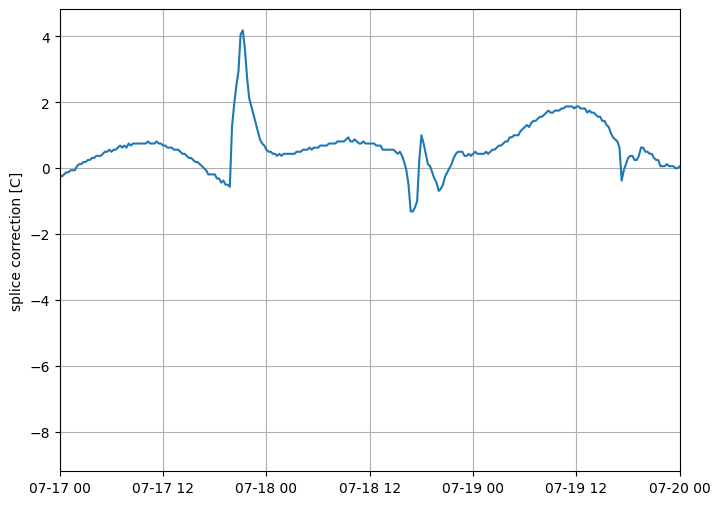

In [23]:
fig, ax = plt.subplots(1, figsize=(8,6))
plt.plot(simba_dates, simba_data['temperature_correction'])
plt.xlim(dt.datetime(2024,7,17), dt.datetime(2024,7,20))
plt.ylabel('splice correction [C]')
# ax.xaxis.set_major_formatter(myFmt)
plt.grid()
plt.show()

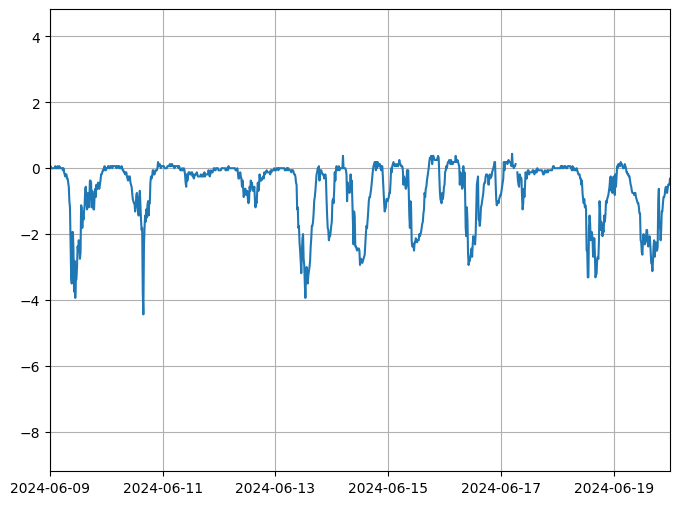

In [24]:
fig, ax = plt.subplots(1, figsize=(8,6))
plt.plot(simba_dates, simba_data['temperature_correction'])
plt.xlim(dt.datetime(2024,6,9), dt.datetime(2024,6,20))
# ax.xaxis.set_major_formatter(myFmt)
plt.grid()
plt.show()

In [26]:
sleigh_vars = ['up_short_hemisp_qc','up_long_hemisp_qc','down_short_hemisp_qc','down_long_hemisp_qc','subsurface_heat_flux_A_qc',
                  'subsurface_heat_flux_B_qc','skin_temp_surface_qc','temp_qc','snow_depth_qc','zenith_true_qc',
                  'down_short_diffuse','down_short_direct','up_short_hemisp','up_long_hemisp','down_short_hemisp','down_long_hemisp',
                  'snow_depth','temp','brightness_temp_surface','skin_temp_surface','subsurface_heat_flux_A','subsurface_heat_flux_B',
                  'subsurface_heat_flux_C','zenith_true','snow_gpr_dist','base_time','time']

asfs_data_lev2 = load_raven_sleigh_data(sleigh_vars)

asfs_data_lev2['net_long_hemisp'] = asfs_data_lev2['down_long_hemisp'] - asfs_data_lev2['up_long_hemisp']
asfs_data_lev2['net_short_hemisp'] = asfs_data_lev2['down_short_hemisp'] - asfs_data_lev2['up_short_hemisp']

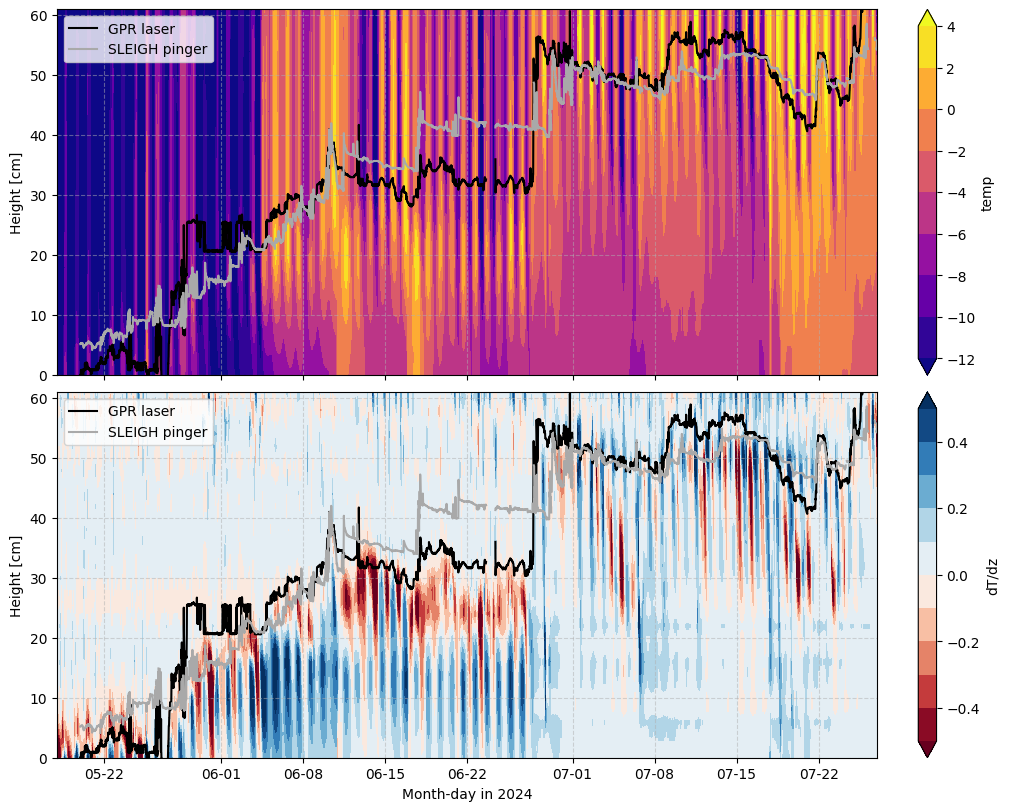

In [27]:
fig, axs = plt.subplots(2, figsize=(10,8), sharex=True, sharey=True, constrained_layout=True)

pltvars = [simba_temps, dTdz]
cmaps = [plt.cm.plasma, plt.cm.RdBu]
levels = [np.arange(-12,5,2), np.arange(-.5,.51,.1)]
labels = ['temp','dT/dz']
for i, ax in enumerate(axs.ravel()):
    
    cb = ax.contourf(simba_dates, simba_heights, np.swapaxes(pltvars[i],0,1),
                    cmap=cmaps[i], levels=levels[i], extend='both')
    ax.plot(asfs_data_lev2['dates'], (asfs_data_lev2['snow_gpr_dist'][0]-asfs_data_lev2['snow_gpr_dist'])*100., label='GPR laser', c='k')
    ax.plot( asfs_data_lev2['dates'], asfs_data_lev2['snow_depth'], label='SLEIGH pinger', c='darkgrey')

    ax.set_ylabel('Height [cm]')
    plt.colorbar(cb, label=labels[i], ax=ax)
    ax.grid(alpha=.5, ls='--')
    ax.set_ylim(0,61)
    ax.set_xlim(dt.datetime(2024,5,18), dt.datetime(2024,7,27))
    ax.xaxis.set_major_formatter(myFmt)
    
    ax.legend(loc='upper left')
axs[-1].set_xlabel('Month-day in 2024')
plt.show()

In [28]:
sleigh_dates = asfs_data_lev2['dates']
sleigh_air_temp = asfs_data_lev2['temp']
sleigh_skin_temp = asfs_data_lev2['skin_temp'] - 273.15
sleigh_swd = asfs_data_lev2['down_short_hemisp']

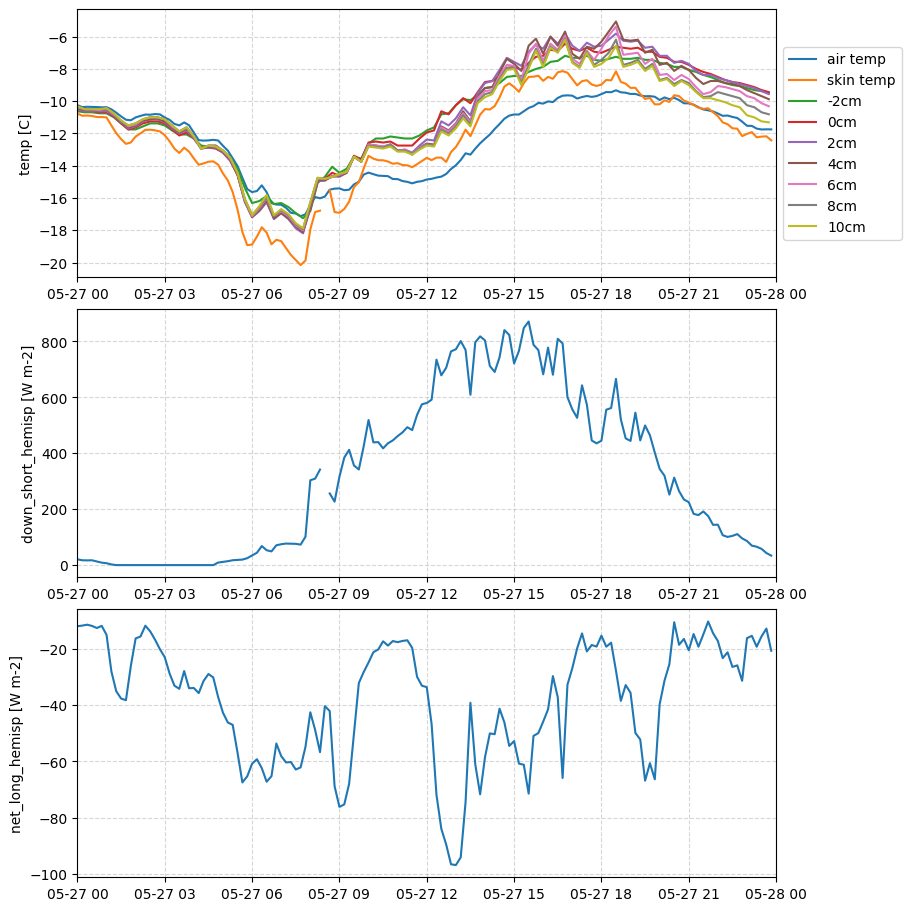

In [29]:
t1, t2 = dt.datetime(2024,5,27), dt.datetime(2024,5,28)
depths = np.arange(-2,11,2)
# depths = np.arange(20,35,2)

simb_time_idx = np.where((simba_dates>=t1)&(simba_dates<t2))
sleigh_time_idx = np.where((sleigh_dates>=t1)&(sleigh_dates<t2))

fig, axs = plt.subplots(3, figsize=(9,9), constrained_layout=True)
axs[0].plot(sleigh_dates[sleigh_time_idx], sleigh_air_temp[sleigh_time_idx], label='air temp')
axs[0].plot(sleigh_dates[sleigh_time_idx], sleigh_skin_temp[sleigh_time_idx], label='skin temp')

flx_var = 'down_short_hemisp'
axs[1].plot(sleigh_dates[sleigh_time_idx], asfs_data_lev2[flx_var][sleigh_time_idx])
axs[1].set_ylabel(f'{flx_var} [W m-2]')

flx_var = 'net_long_hemisp'
axs[2].plot(sleigh_dates[sleigh_time_idx], asfs_data_lev2[flx_var][sleigh_time_idx])
axs[2].set_ylabel(f'{flx_var} [W m-2]')

for d in depths:
    depth_idx = np.where(simba_heights==d)[0]
    axs[0].plot(simba_dates[simb_time_idx], np.squeeze(simba_temps[simb_time_idx[0],:][:,depth_idx]), label=f'{d}cm' )

for ax in axs.ravel():
    ax.set_xlim(t1, t2)
    ax.grid(alpha=.5, ls='--')
    # ax.xaxis.set_major_formatter(myFmt)
axs[0].legend(loc='center left', bbox_to_anchor=(1, .5))
axs[0].set_ylabel('temp [C]')
# axs[-1].set_xlabel('Month-day in 2024')

plt.show()

### Onto interpolating depths

In [13]:
def interp_temp_subset(secs_in, temp_in, mask_index, k=3, s=3):
    t, c, k = interpolate.splrep(secs_in[~mask_index], temp_in[~mask_index], k=k, s=s)
    spline = interpolate.BSpline(t, c, k, extrapolate=True)
    temp_out = spline(secs_in)
    return temp_out

In [14]:
def get_day_subset_idx(dt_start, dates_in, hr_st=10, hr_en=20):
    t1 = dt_start + dt.timedelta(hours=hr_st)
    t2 = dt_start + dt.timedelta(hours=hr_en)

    time_subset_idx = np.where((dates_in>=t1)&(dates_in<t2))
    return time_subset_idx

In [15]:
def daterange(start_date, end_date):
    # from https://stackoverflow.com/questions/1060279/iterating-through-a-range-of-dates-in-python
    days = int((end_date - start_date).days)
    for n in range(days):
        yield start_date + dt.timedelta(n)

In [16]:
def get_temp_subset(depths_in, d_in, temp_in):
    depth_idx = np.where(depths_in==d_in)#[0]

    return np.squeeze(temp_in[:,depth_idx[0]]), depth_idx
    # return temp_in[:,depth_idx[0]], depth_idx

In [17]:
def get_date_subset_idx(dt_start, dates_in, hr_st=10, hr_en=20):
    t1 = dt_start + dt.timedelta(hours=hr_st)
    t2 = dt_start + dt.timedelta(hours=hr_en)

    time_subset_idx = np.where((dates_in>=t1)&(dates_in<t2))
    return time_subset_idx

In [30]:
# need SLEIGH measurements to have same timesteps
sleigh_seconds = datetimes_to_seconds(sleigh_dates)
simba_seconds = datetimes_to_seconds(simba_dates)

skin_t_simba_steps = interpolate_and_mask(sleigh_skin_temp, sleigh_seconds, simba_seconds)
swd_simba_steps = interpolate_and_mask(asfs_data_lev2['down_short_hemisp'], sleigh_seconds, simba_seconds)
lwn_simba_steps = interpolate_and_mask(asfs_data_lev2['net_long_hemisp'], sleigh_seconds, simba_seconds)

In [31]:
first_simba_day = dt.datetime(2024,5,18)

In [32]:
myFmt_hrmin = mdates.DateFormatter('%H:%M')

2024-05-27 00:00:00 2024-05-27 15:30:00
2024-06-20 00:00:00 2024-06-20 17:00:00
2024-06-24 00:00:00 2024-06-24 16:30:00
-34.8768474188691


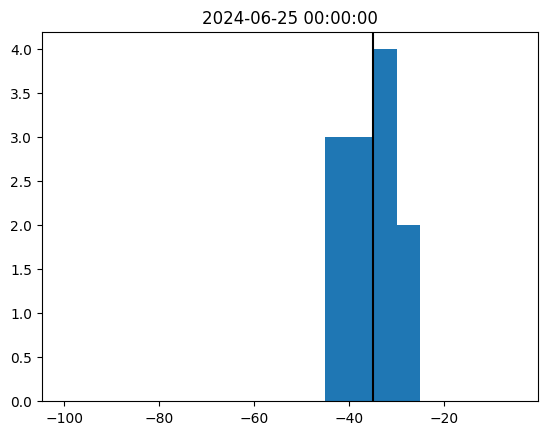

In [33]:
# 

# start_date = dt.datetime(2024,6,15)
# end_date = dt.datetime(2024,6,16) # should go until Jun 27 when bottom thermistor section is no longer used near the surface
start_date = first_simba_day
end_date = dt.datetime(2024,6,27)

copy_temps = simba_temps.copy()
complicated_end = {dt.datetime(2024,5,22):dt.timedelta(hours=16, minutes=30), 
                     dt.datetime(2024,5,25):dt.timedelta(hours=16, minutes=0),
                     dt.datetime(2024,5,22):dt.timedelta(hours=16, minutes=30),}

complicated_start = {dt.datetime(2024,5,27):{'en_mask':dt.timedelta(hours=15, minutes=30), 
                                             'hr_st':14, 'st_mask':dt.timedelta(hours=15, minutes=0)},
                    dt.datetime(2024,6,20):{'en_mask':dt.timedelta(hours=17, minutes=0), 
                                             'hr_st':10, 'st_mask':dt.timedelta(hours=14, minutes=30)},
                    dt.datetime(2024,6,24):{'en_mask':dt.timedelta(hours=16, minutes=30), 
                                             'hr_st':10, 'st_mask':dt.timedelta(hours=14, minutes=30)},
                    }

for single_date in daterange(start_date, end_date):
    
    if single_date in complicated_start:
        st_hr = complicated_start[single_date]['hr_st']
    else:
        st_hr = 10
    simb_time_idx = get_day_subset_idx(single_date, simba_dates, hr_st=st_hr)

    # this could be better code: make a more general fucntion for get_day_subset_idx()
    # st_mask = single_date+dt.timedelta(hours=14)


    # these dates were cloudy at 1700 and so the tmeperatures after are very noisy near the surface/at,
    # increase the smoothness factor (s) and limit the interpoalted time period to pre-clouds
    # this is based on photos, but should maybe use LWN to generalize it?
    if single_date in complicated_end:
        s=15
        st_mask = single_date+dt.timedelta(hours=14)
        en_mask = single_date+complicated_end[single_date]
    elif single_date in complicated_start:
        s=15
        st_mask = single_date+complicated_start[single_date]['st_mask']
        en_mask = single_date+complicated_start[single_date]['en_mask']
        print(single_date, en_mask)
    else:
        s=3
        st_mask = single_date+dt.timedelta(hours=14)
        en_mask = single_date+dt.timedelta(hours=17, minutes=30)

    
    # this should be maded consistent with other masking?
    mask_time_subset = get_date_subset_idx(single_date, simba_dates, hr_st=14, hr_en=17)
    single_day_lwn = lwn_simba_steps[mask_time_subset]
    if single_date==dt.datetime(2024,6,25):
        print(single_day_lwn.mean())
        plt.hist(single_day_lwn[~single_day_lwn.mask].flatten(), bins=np.arange(-100,0,5))
        plt.axvline(x=single_day_lwn.mean(), c='k')
        plt.title(single_date)
        plt.show()
    if single_day_lwn.mean()>-50:
        continue
        


    


        # # only want to interpolate if it's clear sky
        # plt.hist(single_day_lwn[~single_day_lwn.mask].flatten(), bins=np.arange(-100,0,5))
        # plt.axvline(x=single_day_lwn.mean(), c='k')
        # plt.title(single_date)
        # plt.show()
        # continue
    
    single_day_temps = simba_temps[simb_time_idx[0],:]
    single_day_seconds = simba_seconds[simb_time_idx]
    single_day_dates = simba_dates[simb_time_idx]

    ## NEED TO ADD CAVEAT/THRESHOLD/ETC TO ONLY DO THIS FOR CLEAR SKIES, IE WHEN LWN<-40?
    

    # end at top level from bottom/free standing thermistor string
    # bottom level is meant to be below any influence - should makee some sort of threshold for when this isn't applied?
    for d in range (-40,47, 2):
        single_day_level_temp, d_index = get_temp_subset(simba_heights, d, single_day_temps)

        # this line could maybe go out of this for loop?
        masked_temp = np.ma.masked_where((single_day_dates>st_mask)&(single_day_dates<en_mask), single_day_level_temp)

        interped_temp = interp_temp_subset(single_day_seconds, single_day_level_temp, masked_temp.mask, k=3, s=s)

        copy_temps[simb_time_idx[0][masked_temp.mask],d_index[0]] = np.squeeze(interped_temp)[masked_temp.mask]
        # print(single_date, d)
        # print(en_mask)
        if single_date==dt.datetime(2024,6,25):
            fig, ax = plt.subplots(1)
            plt.grid()
            plt.title(d)
            plt.plot(single_day_dates, single_day_level_temp)
            plt.plot(single_day_dates, masked_temp, ls='--')
            plt.plot(single_day_dates, interped_temp, ls=':', c='r')
            ax.xaxis.set_major_formatter(myFmt_hrmin)
            plt.axvline(x=en_mask, c='k')
            plt.axvline(x=st_mask, c='k')

            plt.xlabel('Hour in day')
            plt.show()

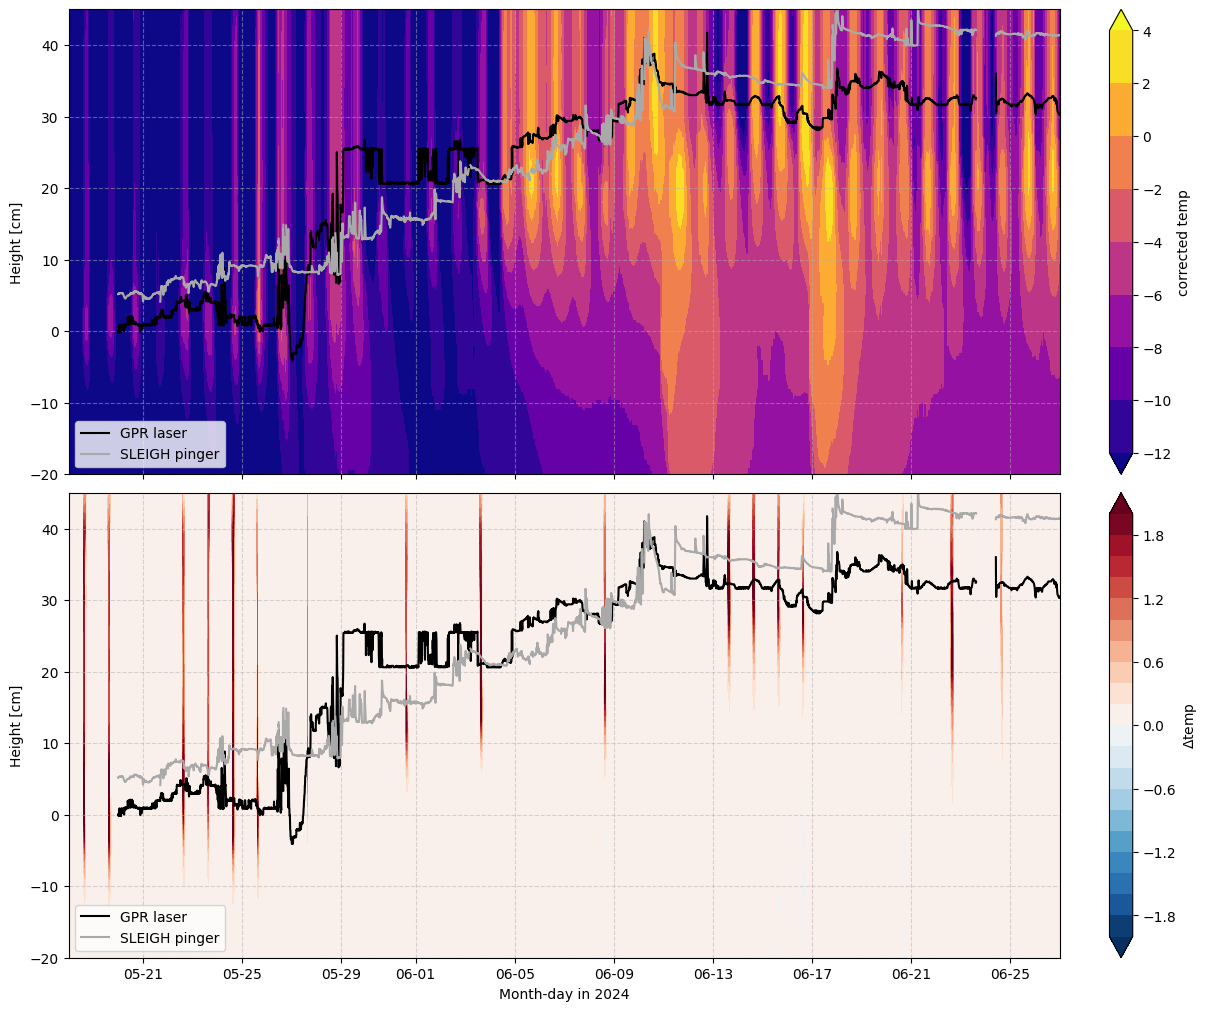

In [34]:
fig, axs = plt.subplots(2, figsize=(12,10), sharex=True, sharey=True, constrained_layout=True)

pltvars = [copy_temps, copy_temps-simba_temps]
cmaps = [plt.cm.plasma, plt.cm.RdBu_r]
levels = [np.arange(-12,5,2), np.arange(-2,2.1,.2)]
labels = ['corrected temp','$\Delta$temp']
for i, ax in enumerate(axs.ravel()):
    
    cb = ax.contourf(simba_dates, simba_heights, np.swapaxes(pltvars[i],0,1),
                    cmap=cmaps[i], levels=levels[i], extend='both')
    ax.plot(asfs_data_lev2['dates'], (asfs_data_lev2['snow_gpr_dist'][0]-asfs_data_lev2['snow_gpr_dist'])*100., label='GPR laser', c='k')
    ax.plot( asfs_data_lev2['dates'], asfs_data_lev2['snow_depth'], label='SLEIGH pinger', c='darkgrey')

    ax.set_ylabel('Height [cm]')
    plt.colorbar(cb, label=labels[i], ax=ax)
    ax.grid(alpha=.5, ls='--')
    ax.set_ylim(-20,45)
    # ax.set_xlim(dt.datetime(2024,6,19), dt.datetime(2024,6,21))
    ax.set_xlim(start_date, end_date)
    ax.xaxis.set_major_formatter(myFmt)
    
    ax.legend(loc='lower left')
axs[-1].set_xlabel('Month-day in 2024')
plt.show()

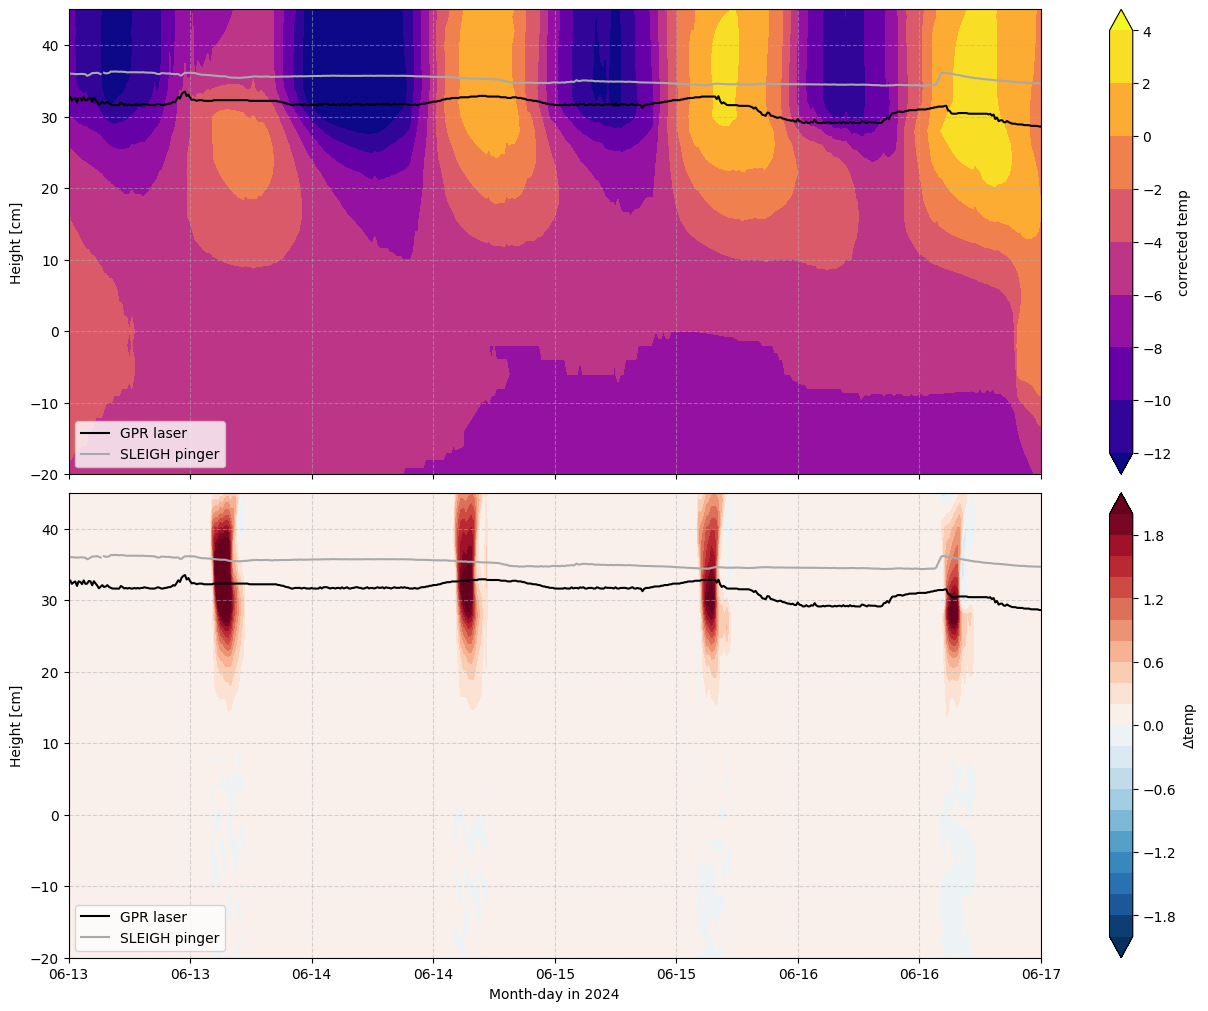

In [46]:
fig, axs = plt.subplots(2, figsize=(12,10), sharex=True, sharey=True, constrained_layout=True)

pltvars = [copy_temps, copy_temps-simba_temps]
cmaps = [plt.cm.plasma, plt.cm.RdBu_r]
levels = [np.arange(-12,5,2), np.arange(-2,2.1,.2)]
labels = ['corrected temp','$\Delta$temp']
for i, ax in enumerate(axs.ravel()):
    
    cb = ax.contourf(simba_dates, simba_heights, np.swapaxes(pltvars[i],0,1),
                    cmap=cmaps[i], levels=levels[i], extend='both')
    ax.plot(asfs_data_lev2['dates'], (asfs_data_lev2['snow_gpr_dist'][0]-asfs_data_lev2['snow_gpr_dist'])*100., label='GPR laser', c='k')
    ax.plot( asfs_data_lev2['dates'], asfs_data_lev2['snow_depth'], label='SLEIGH pinger', c='darkgrey')

    ax.set_ylabel('Height [cm]')
    plt.colorbar(cb, label=labels[i], ax=ax)
    ax.grid(alpha=.5, ls='--')
    ax.set_ylim(-20,45)
    ax.set_xlim(dt.datetime(2024,6,13), dt.datetime(2024,6,17))
    # ax.set_xlim(start_date, end_date)
    ax.xaxis.set_major_formatter(myFmt)
    
    ax.legend(loc='lower left')
axs[-1].set_xlabel('Month-day in 2024')
plt.show()

In [36]:
temp_correction_diff = np.ma.masked_invalid(copy_temps-simba_temps)

In [37]:
print(temp_correction_diff.max(), temp_correction_diff.min())

5.126462896136525 -2.630587537836143


In [38]:
masked_temp_correction_diff = np.ma.masked_where(np.abs(temp_correction_diff)<.1, temp_correction_diff)

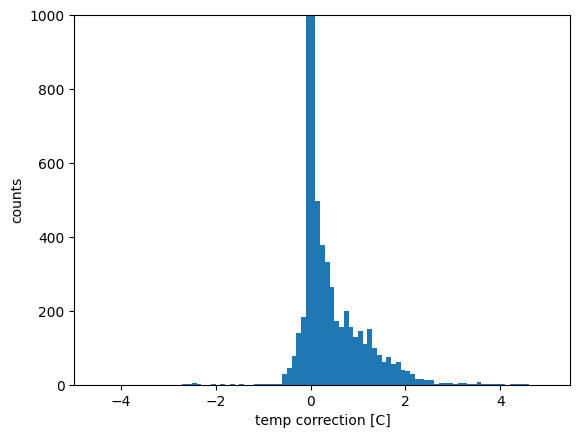

In [39]:
plt.hist(temp_correction_diff[~temp_correction_diff.mask].flatten(), bins=np.arange(-4.5,5.01,.1))
plt.xlabel('temp correction [C]')
plt.ylabel('counts')
plt.ylim(0,1000)
plt.show()

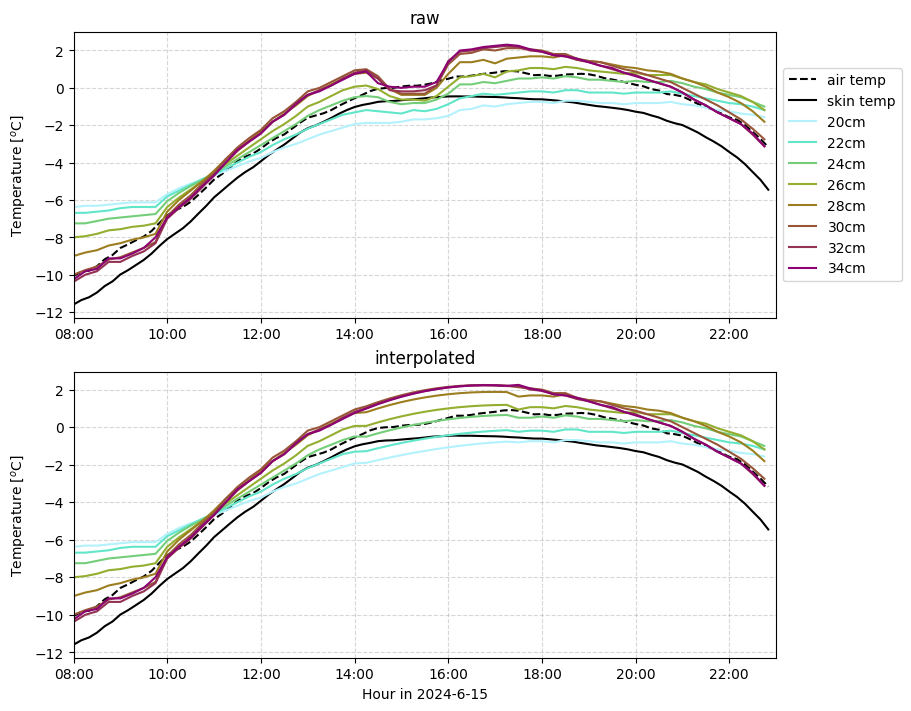

In [60]:
t1, t2 = dt.datetime(2024,6,15,8), dt.datetime(2024,6,15,23)
# depths = np.arange(-2,11,2)
depths = np.arange(20,35,2)

hrFmt = mdates.DateFormatter('%H:%M')

# more aesthetically pleasing colors for lines
cmap = cmr.hawaii_r
num_colors = len(depths)
color_list = [cmap(i) for i in np.linspace(0, 1, num_colors)]

simb_time_idx = np.where((simba_dates>=t1)&(simba_dates<t2))
sleigh_time_idx = np.where((sleigh_dates>=t1)&(sleigh_dates<t2))

fig, axs = plt.subplots(2, figsize=(9,7), constrained_layout=True)

titles = ['raw', 'interpolated']
for i, ax in enumerate(axs.ravel()):
    ax.plot(sleigh_dates[sleigh_time_idx], sleigh_air_temp[sleigh_time_idx], label='air temp', c='k', ls='--')
    ax.plot(sleigh_dates[sleigh_time_idx], sleigh_skin_temp[sleigh_time_idx], label='skin temp', c='k')

    ax.set_xlim(t1, t2)
    ax.grid(alpha=.5, ls='--')
    ax.set_ylabel('Temperature [$^o$C]')
    ax.xaxis.set_major_formatter(hrFmt)
    ax.set_title(titles[i])

for d, c in zip(depths, color_list):
    depth_idx = np.where(simba_heights==d)[0]
    axs[0].plot(simba_dates[simb_time_idx], np.squeeze(simba_temps[simb_time_idx[0],:][:,depth_idx]), label=f'{d}cm', c=c )

    axs[1].plot(simba_dates[simb_time_idx], np.squeeze(copy_temps[simb_time_idx[0],:][:,depth_idx]), label=f'{d}cm', c=c )



axs[0].legend(loc='center left', bbox_to_anchor=(1, .5))

axs[-1].set_xlabel(f'Hour in {t1.year}-{t1.month}-{t1.day}')

plt.show()

## make some plots for sanity checks

In [375]:
dTdz_interp = np.gradient(copy_temps, simba_heights,  axis=1)
dTdz_diff = dTdz_interp - dTdz

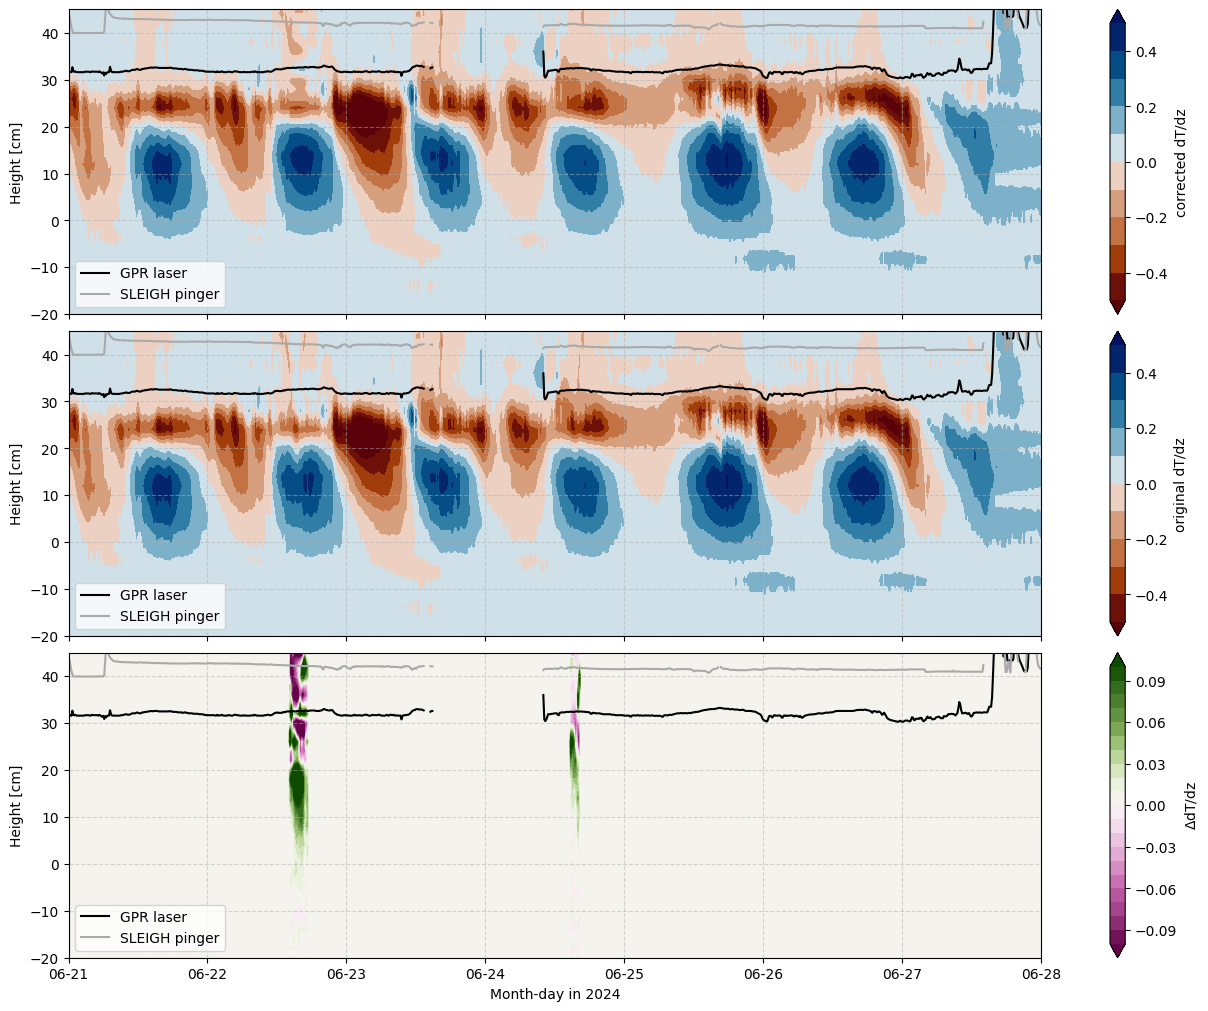

In [382]:
fig, axs = plt.subplots(3, figsize=(12,10), sharex=True, sharey=True, constrained_layout=True)

pltvars = [dTdz_interp, dTdz, dTdz_diff]
cmaps = [cmr.vik_r, cmr.vik_r, cmr.bam]
levels = [np.arange(-.5,.51,.1),np.arange(-.5,.51,.1), np.arange(-.1,.11,.01)]
labels = ['corrected dT/dz','original dT/dz','$\Delta$dT/dz']
for i, ax in enumerate(axs.ravel()):
    
    cb = ax.contourf(simba_dates, simba_heights, np.swapaxes(pltvars[i],0,1),
                    cmap=cmaps[i], levels=levels[i], extend='both')
    ax.plot(asfs_data_lev2['dates'], (asfs_data_lev2['snow_gpr_dist'][0]-asfs_data_lev2['snow_gpr_dist'])*100., label='GPR laser', c='k')
    ax.plot( asfs_data_lev2['dates'], asfs_data_lev2['snow_depth'], label='SLEIGH pinger', c='darkgrey')

    ax.set_ylabel('Height [cm]')
    plt.colorbar(cb, label=labels[i], ax=ax)
    ax.grid(alpha=.5, ls='--')
    ax.set_ylim(-20,45)
    ax.set_xlim(dt.datetime(2024,6,21), dt.datetime(2024,6,28))
    # ax.set_xlim(start_date, end_date)
    ax.xaxis.set_major_formatter(myFmt)
    
    ax.legend(loc='lower left')
axs[-1].set_xlabel('Month-day in 2024')
plt.show()

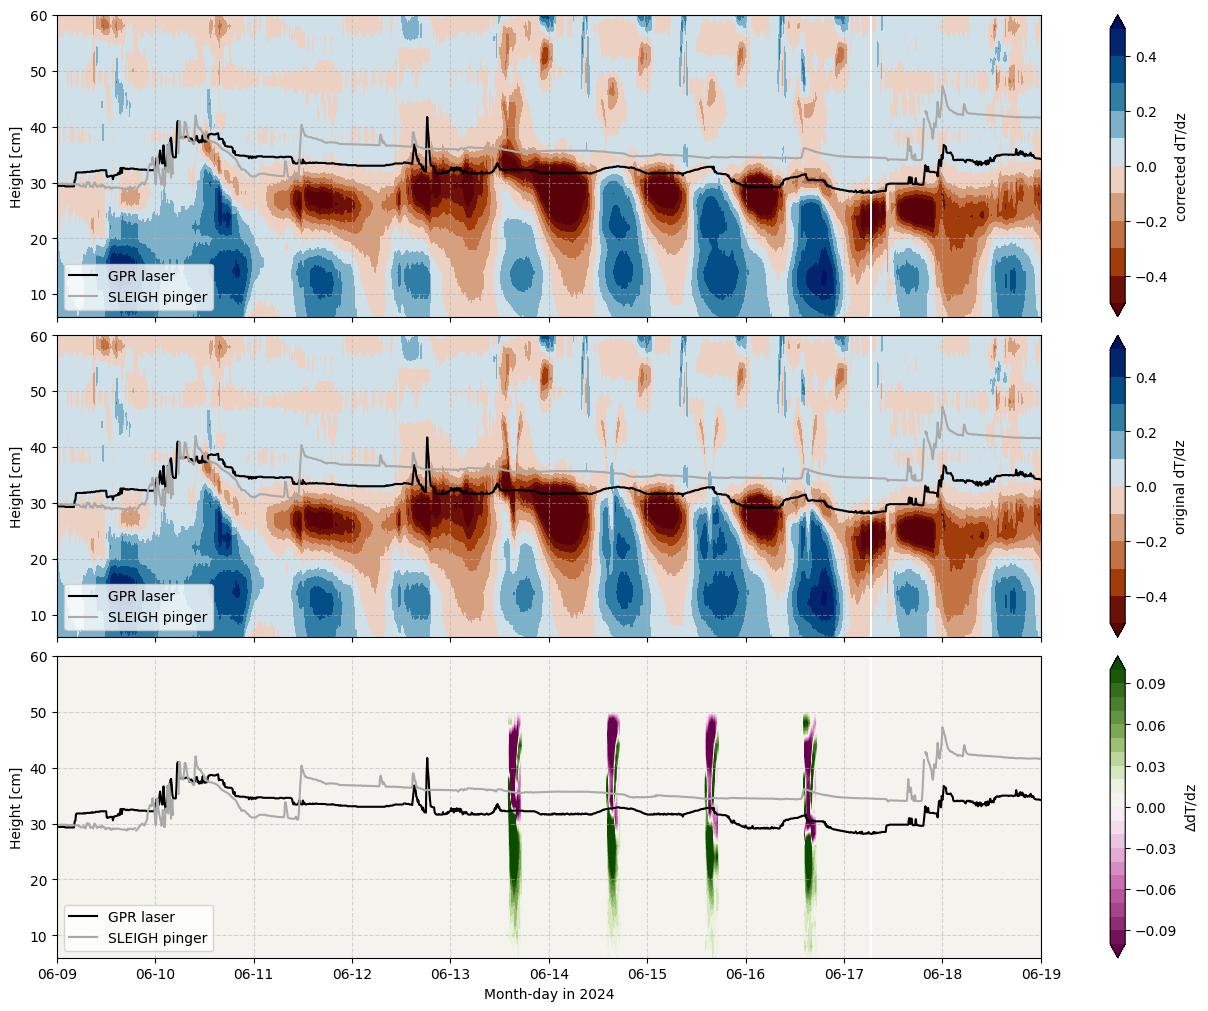

In [408]:
fig, axs = plt.subplots(3, figsize=(12,10), sharex=True, sharey=True, constrained_layout=True)

pltvars = [dTdz_interp, dTdz, dTdz_diff]
cmaps = [cmr.vik_r, cmr.vik_r, cmr.bam]
levels = [np.arange(-.5,.51,.1),np.arange(-.5,.51,.1), np.arange(-.1,.11,.01)]
labels = ['corrected dT/dz','original dT/dz','$\Delta$dT/dz']
for i, ax in enumerate(axs.ravel()):
    
    cb = ax.contourf(simba_dates, simba_heights, np.swapaxes(pltvars[i],0,1),
                    cmap=cmaps[i], levels=levels[i], extend='both')
    ax.plot(asfs_data_lev2['dates'], (asfs_data_lev2['snow_gpr_dist'][0]-asfs_data_lev2['snow_gpr_dist'])*100., label='GPR laser', c='k')
    ax.plot( asfs_data_lev2['dates'], asfs_data_lev2['snow_depth'], label='SLEIGH pinger', c='darkgrey')

    ax.set_ylabel('Height [cm]')
    plt.colorbar(cb, label=labels[i], ax=ax)
    ax.grid(alpha=.5, ls='--')
    ax.set_ylim(6,60)
    ax.set_xlim(dt.datetime(2024,6,9), dt.datetime(2024,6,19))
    # ax.set_xlim(start_date, end_date)
    ax.xaxis.set_major_formatter(myFmt)
    
    ax.legend(loc='lower left')
axs[-1].set_xlabel('Month-day in 2024')
plt.show()

In [391]:
print(dt.date.today())

2025-09-18


In [394]:
# fn = 'firnprofile_solar-correction_rolling-variance-sfc_created_20250722.nc'
# fn = 'firnprofile_solar-correction_max-daytime-d2Tdz2-sfc_created_20250722.nc'
fn = f'firnprofile_solar-shading-corrected.nc'

with Dataset(f'/psd3data/arctic/sledd/Raven_simba/{fn}', 'w', format='NETCDF4_CLASSIC') as ds:
    # ds.title='SIMBA data from Raven corrected for suspected solar bias. Created in simba_correction_new-sfc.ipynb \
    #             using firnprofile-combined-corrected-maxheight.sled.level2.beta.15min.20240517-20240814_created_Apr8_2025.nc.\
    #             Extinction coefficent was set to linearly change between 10 and 15 m-1 (ks_i = [10,15]). NIR fraction was 0.5, \
    #             and there was no adjustment to the surface (sfc_dif_i = 0.). Curve fitting was done using the uper 85 percentile of\
    #             SW bins and a functional curve of the form b*(x / (a + x)) for two wind speed bins, 0-4 and 4-25 m/s.\
    #             Surface used was Raven2024_SIMBA_sfc_id_combined-corrected-maxheight_raw-despiked-72h-05threshold_20250416.csv.'
    ds.title=f'SIMBA data from Raven corrected for solar shading from SIMBA support for bottom section of thermistor. Created in simba_solar-shading-interp.ipynb on {dt.date.today()}'
    
    time = ds.createDimension('time', None)
    times = ds.createVariable('time', np.float64, ('time',))
    times[:] = np.squeeze(simba_seconds)
    times.units = 'seconds since 1970-01-01 00:00'
    times.calendar = 'standard'
    
    depth = ds.createDimension('initial_height', len(simba_heights))
    depths = ds.createVariable('initial_height', np.float64, ('initial_height',))
    depths[:] = simba_heights
    depths.units = 'cm'
    
    
    value = ds.createVariable('temperature', np.float64, ('time','initial_height',))
    value.missing_value = -999
    value.units = 'C'
    value[:] = copy_temps

    value = ds.createVariable('shading_correction', np.float64, ('time','initial_height',))
    value.missing_value = -999
    value.units = 'C'
    value[:] = temp_correction_diff

# ds.close()

## everything below is old, probably delete in future

In [ ]:
t1, t2 = dt.datetime(2024,6,14,8), dt.datetime(2024,6,14,22) ## the specific hours used matter for getting the best spline fit 
d = 34 # will have to do interpolation over each level
simb_time_idx = np.where((bottom_dates>=t1)&(bottom_dates<t2))
depth_idx = np.where(bottom_depths==d)[0]

test_temp_level_day = np.squeeze(bottom_temps[simb_time_idx[0],:][:,depth_idx])

test_day_dates = bottom_dates[simb_time_idx]
test_day_seconds = datetimes_to_seconds(test_day_dates)

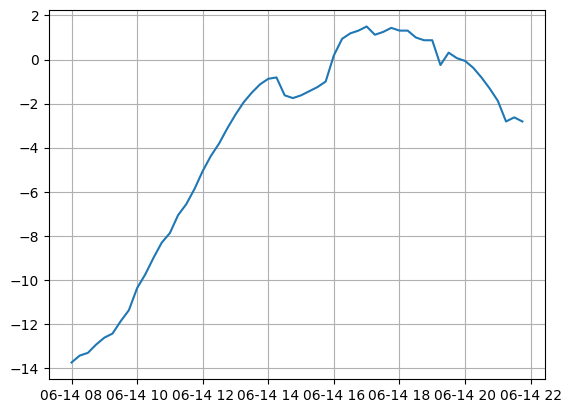

In [186]:
plt.plot(test_day_dates, np.squeeze(test_temp_level_day), label=d )
plt.grid()
plt.show()

In [195]:
## should be mask around 14-17 hours of each day; need to adjust for starting hour

st_mask = t1+dt.timedelta(hours=6)
en_mask = t1+dt.timedelta(hours=9)#, minutes=30)
masked_test_data = np.ma.masked_where((test_day_dates>=st_mask)&(test_day_dates<en_mask), test_temp_level_day)

In [188]:
t, c, k = interpolate.splrep(test_day_seconds[~masked_test_data.mask], 
                             test_temp_level_day[~masked_test_data.mask], k=3, s=3)
spline = interpolate.BSpline(t, c, k, extrapolate=True)
outdata = spline(test_day_seconds)



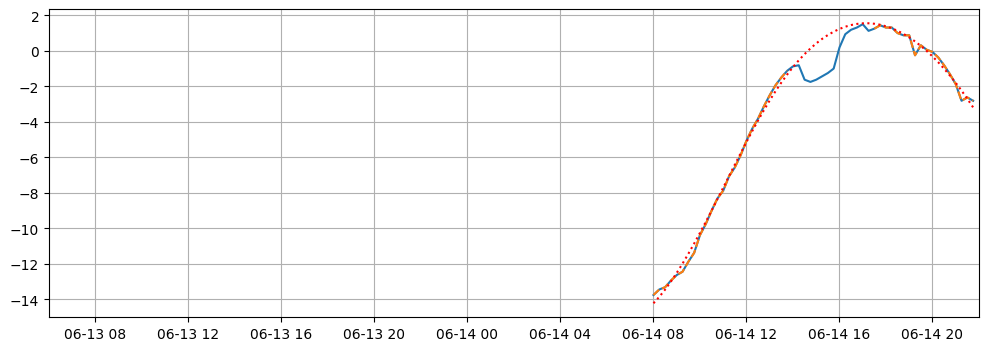

In [189]:
fig, ax = plt.subplots(1, figsize=(12,4))
plt.plot(test_day_dates, test_temp_level_day, label=d )
plt.plot(test_day_dates, masked_test_data, label='mask', ls='--' )
plt.plot(test_day_dates, outdata, label='poly', ls=':', c='r' )
plt.xlim(day_st, t2)
plt.grid()
plt.show()

-10 (56,)


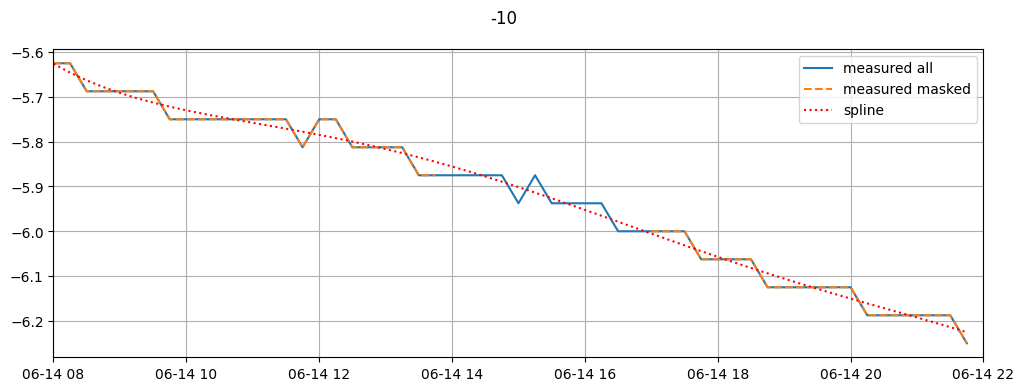

-8 (56,)


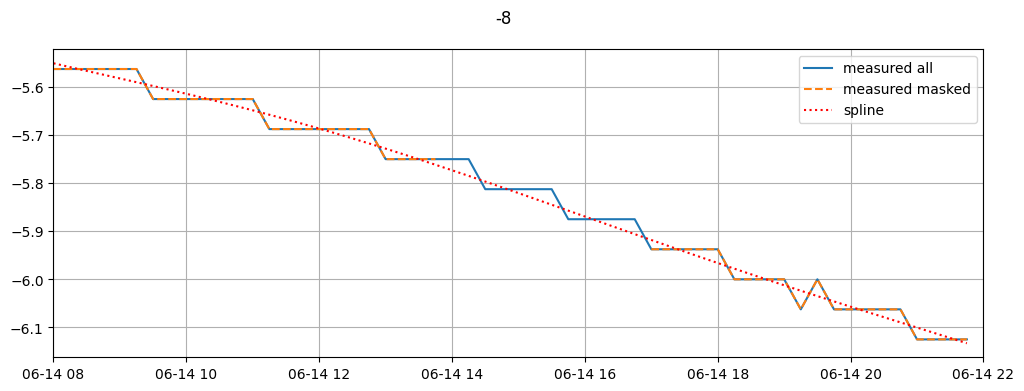

-6 (56,)


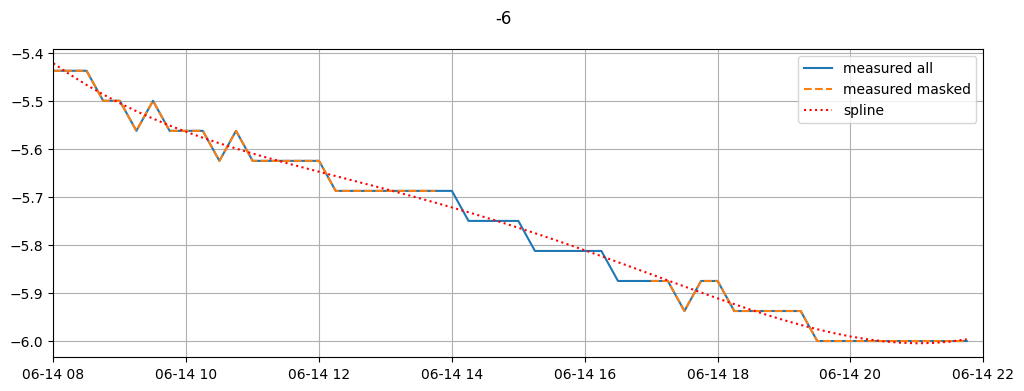

-4 (56,)


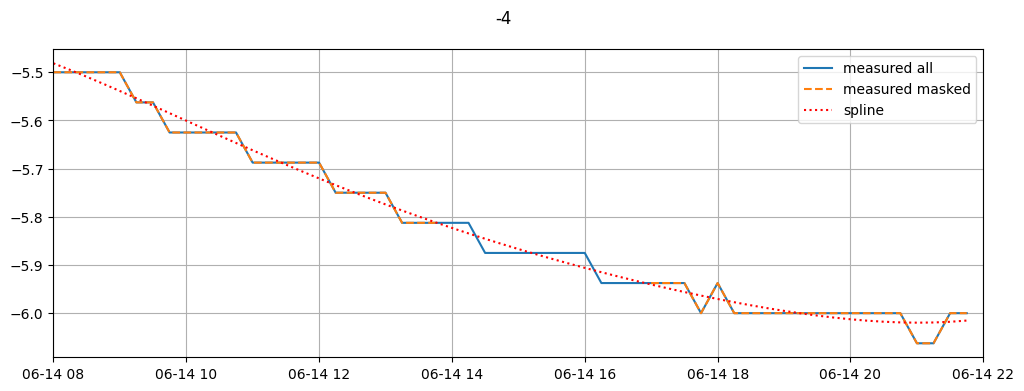

-2 (56,)


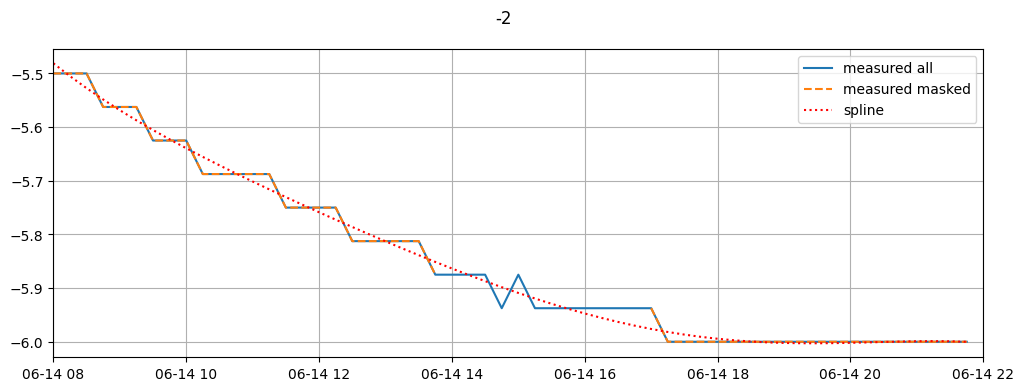

0 (56,)


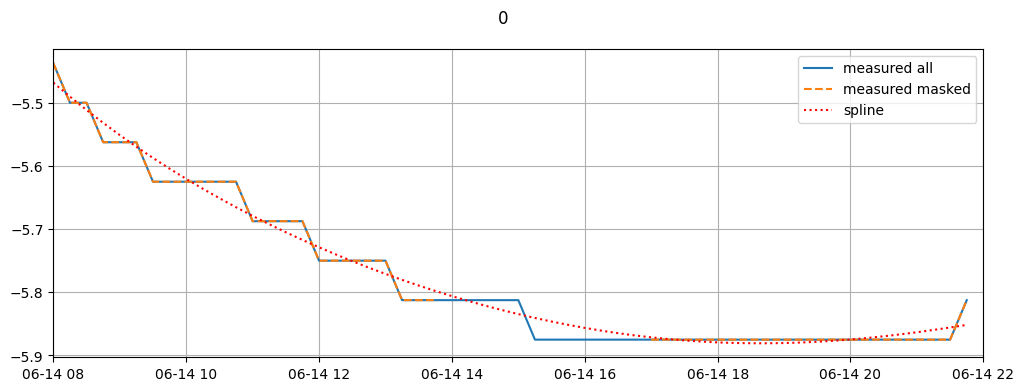

2 (56,)


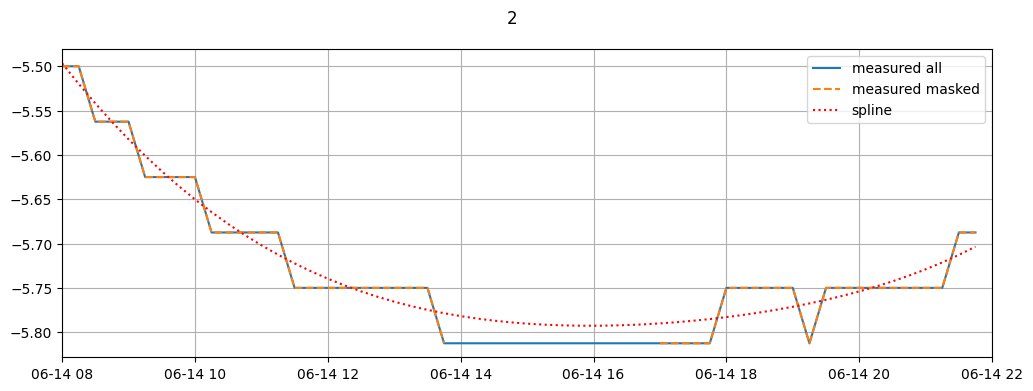

4 (56,)


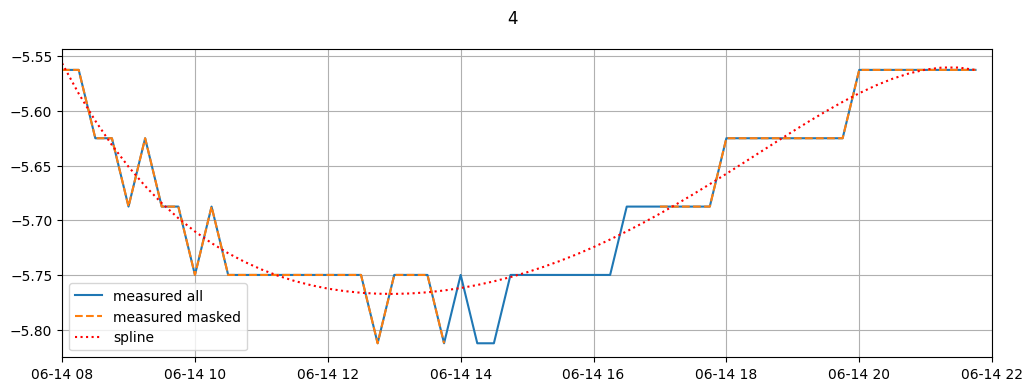

6 (56,)


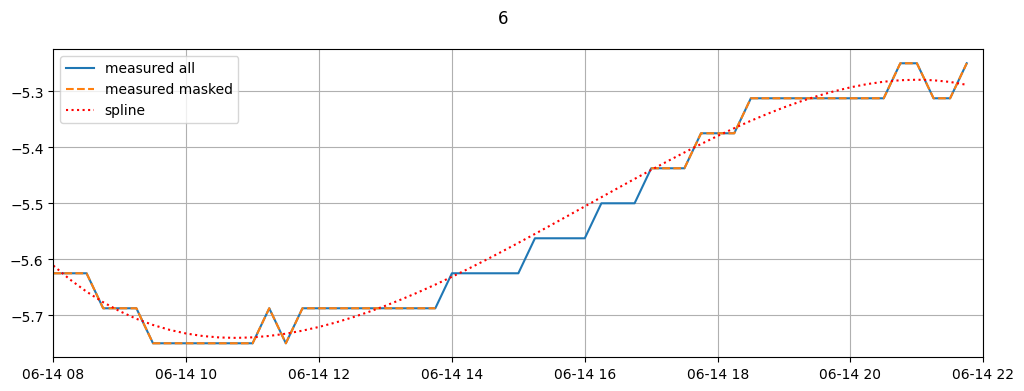

8 (56,)


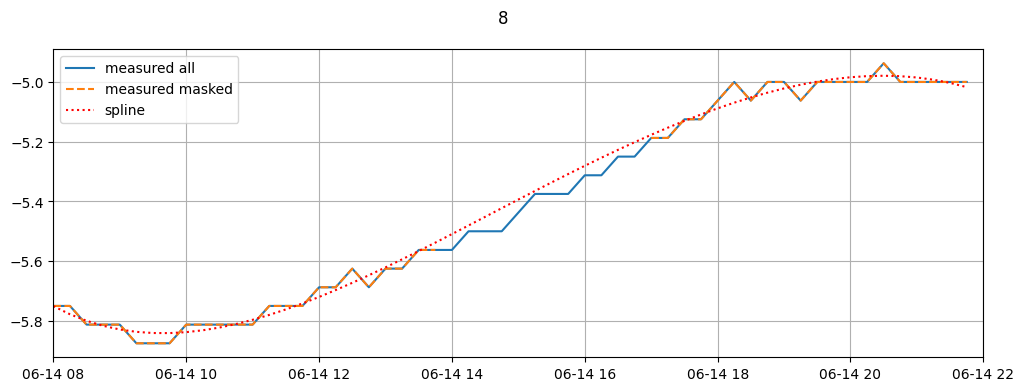

10 (56,)


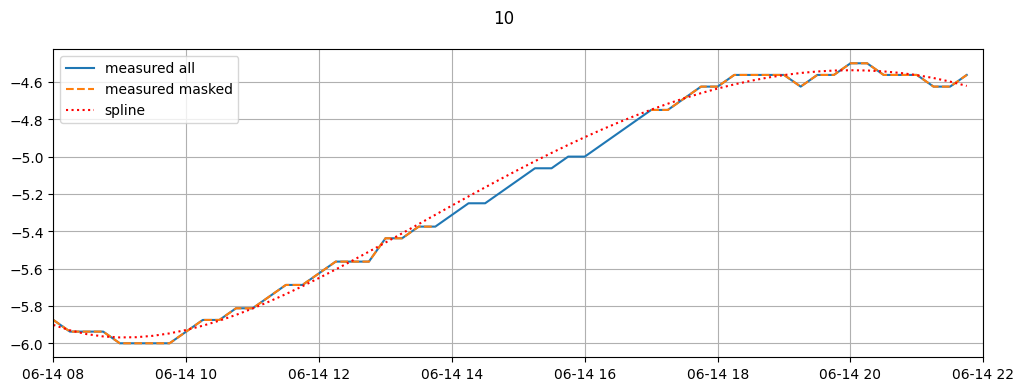

12 (56,)


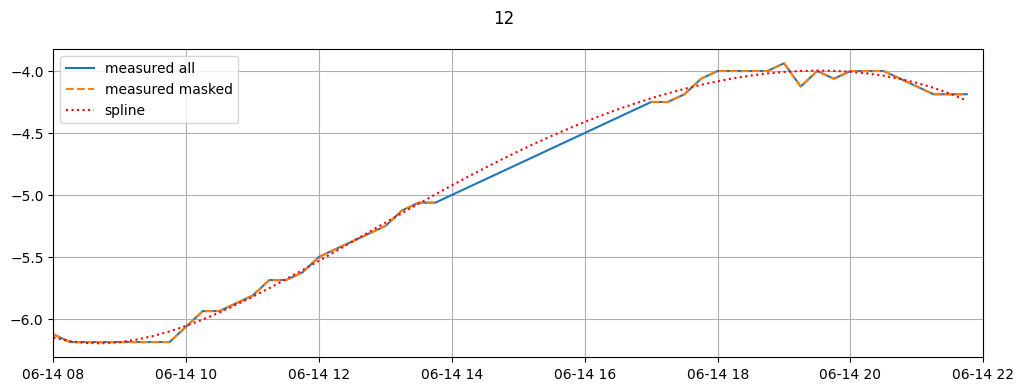

14 (56,)


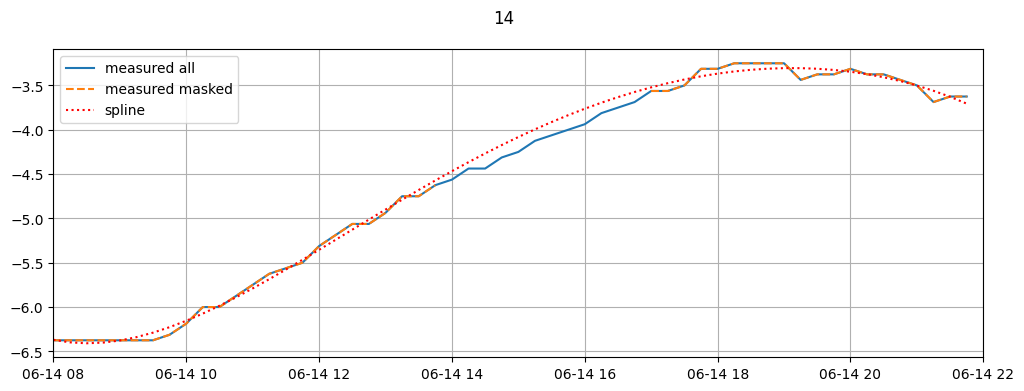

16 (56,)


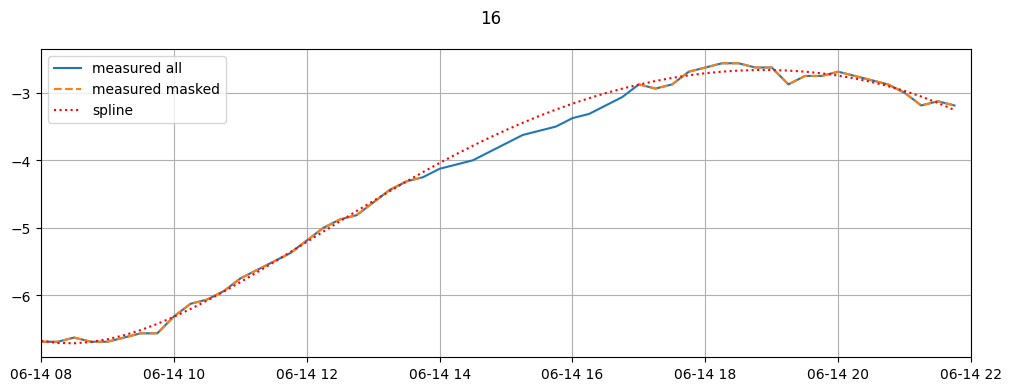

18 (56,)


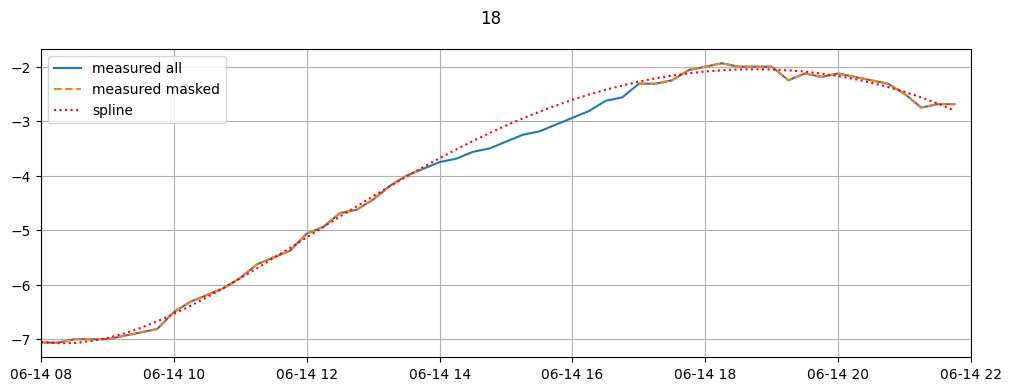

20 (56,)


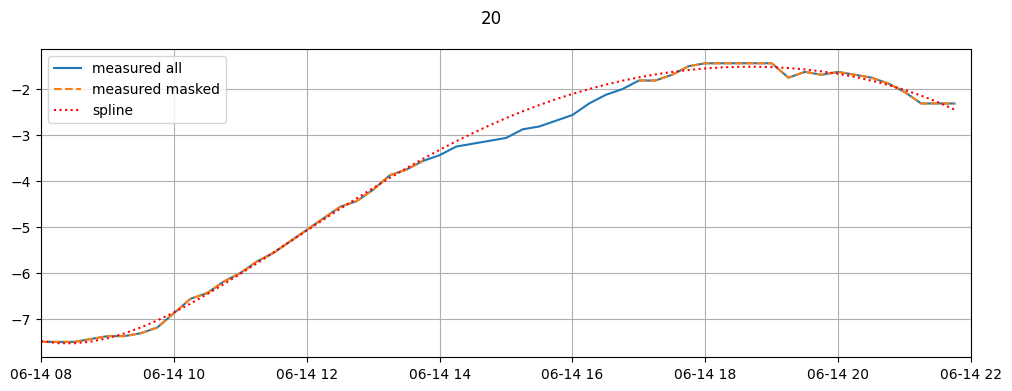

22 (56,)


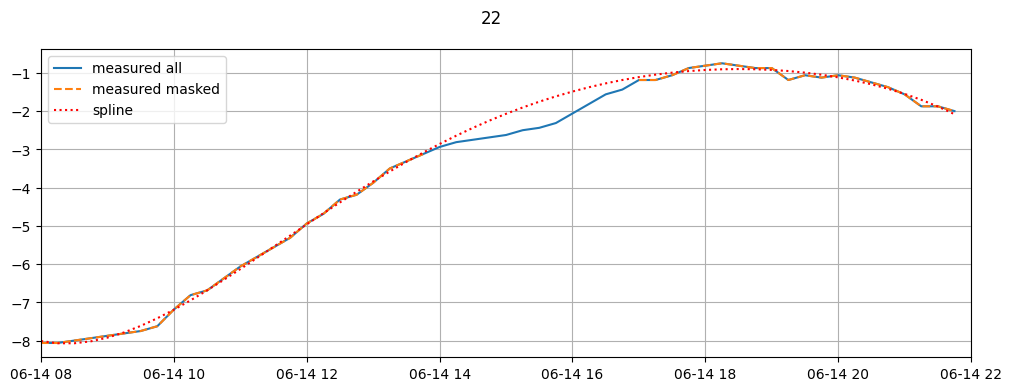

24 (56,)


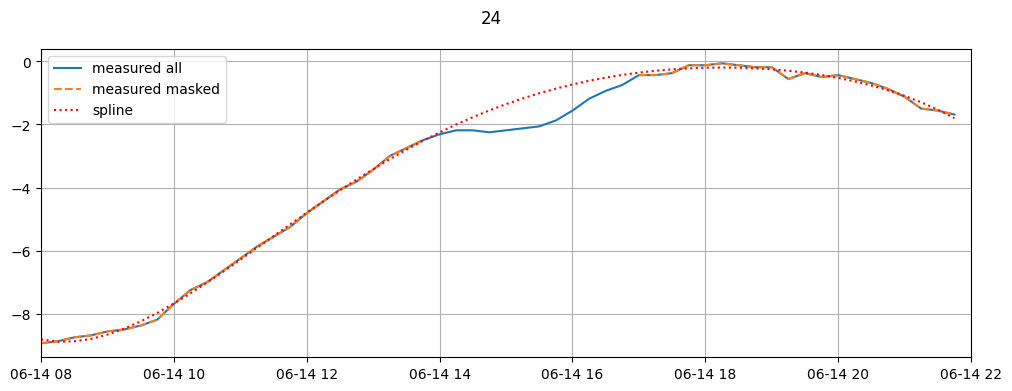

26 (56,)


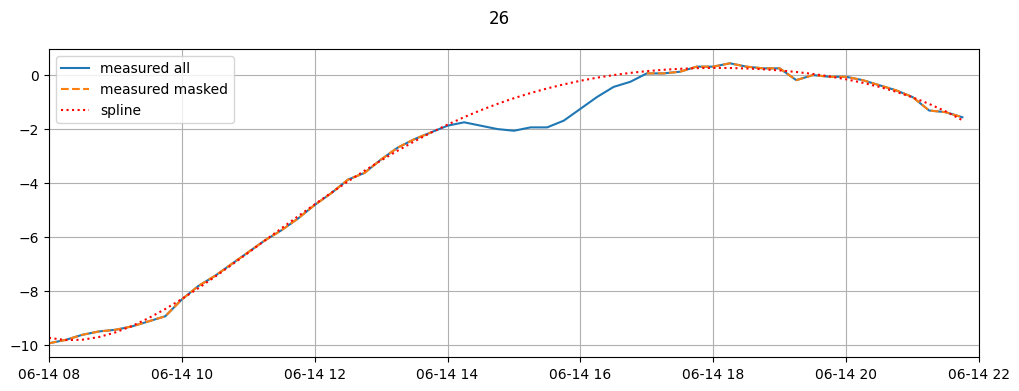

28 (56,)


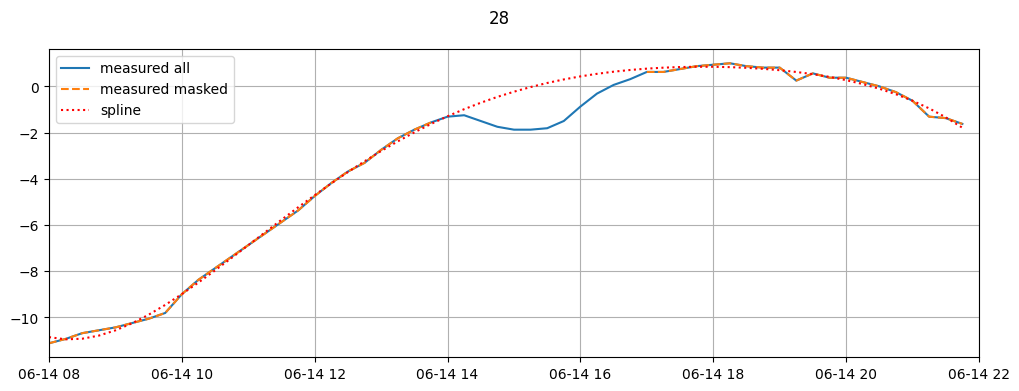

30 (56,)


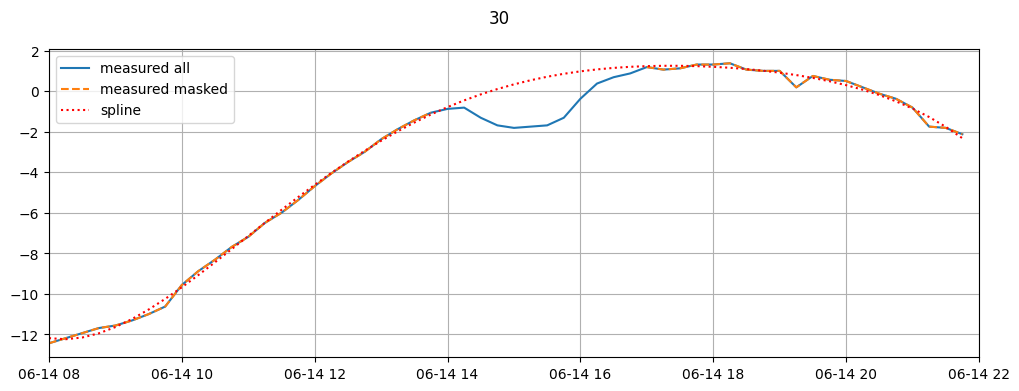

32 (56,)


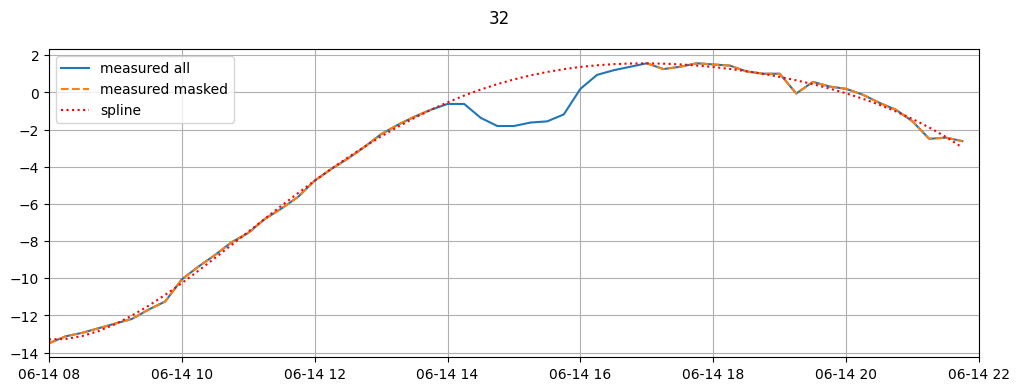

34 (56,)


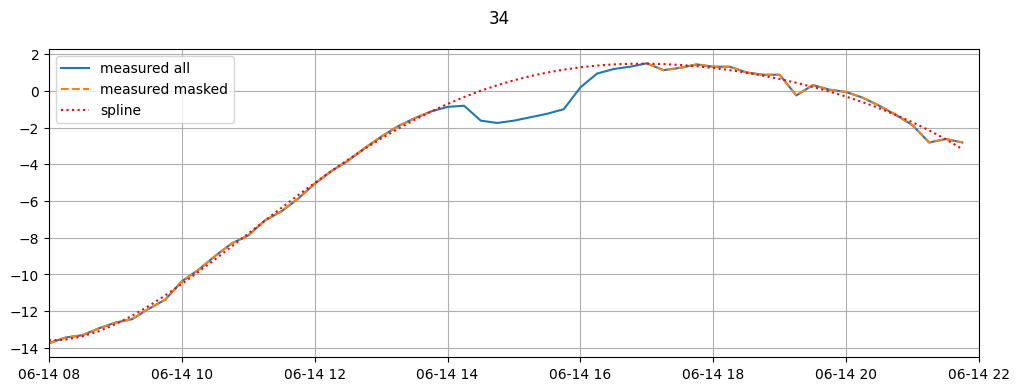

36 (56,)


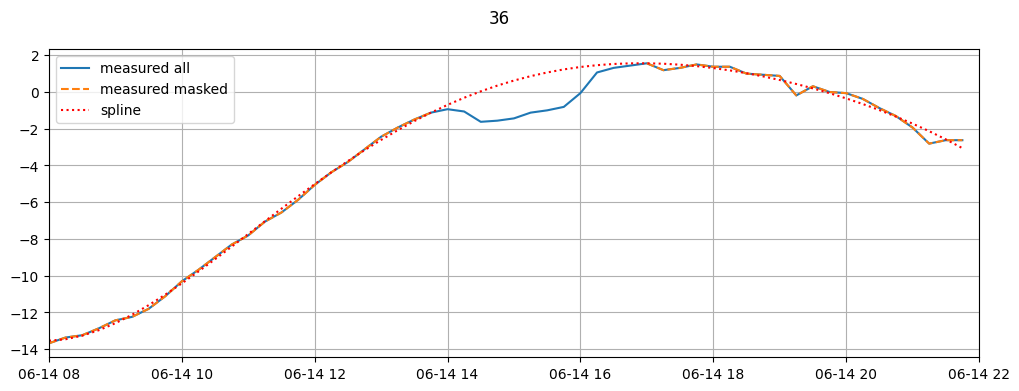

38 (56,)


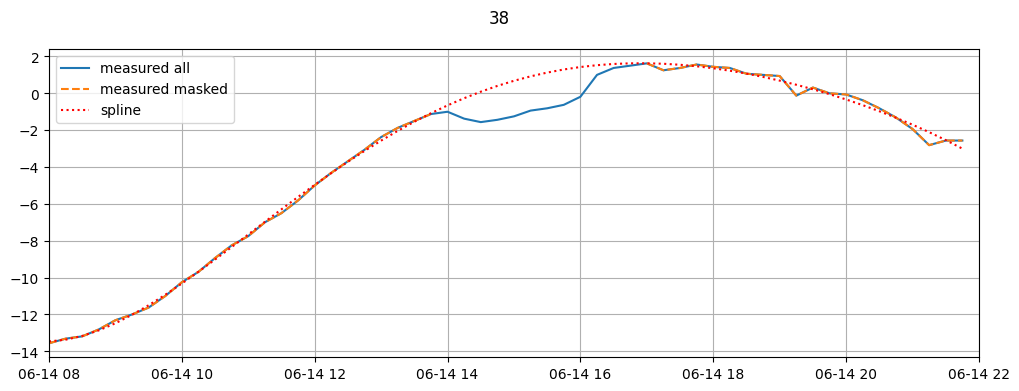

40 (56,)


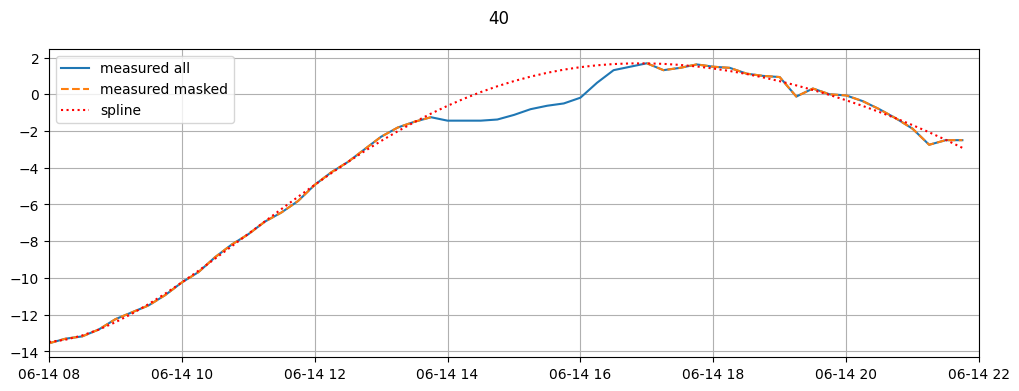

42 (56,)


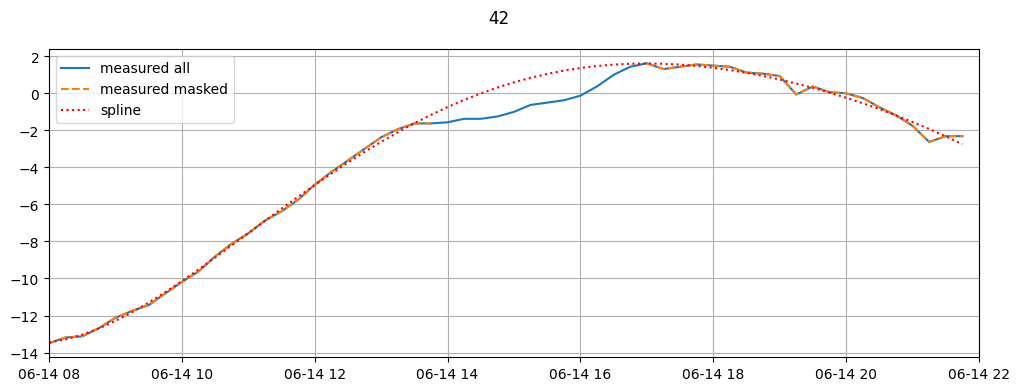

44 (56,)


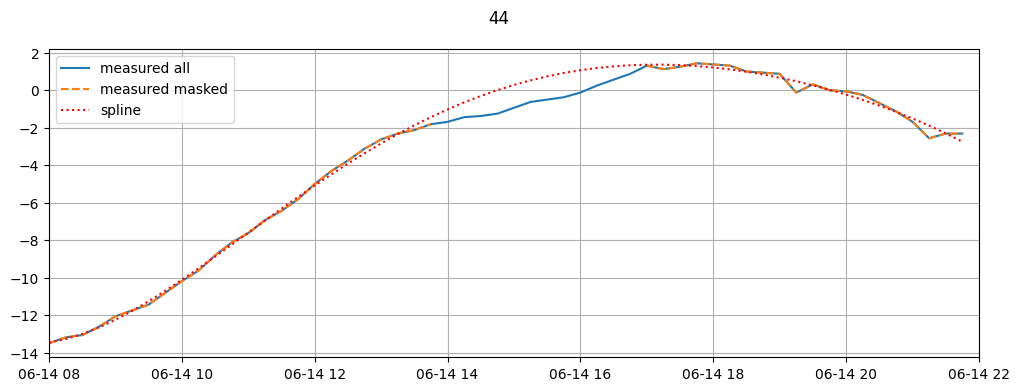

46 (56,)


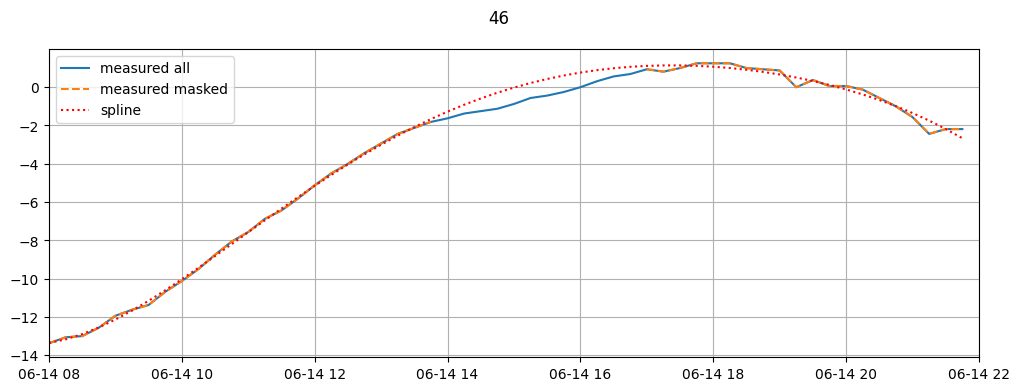

48 (56,)


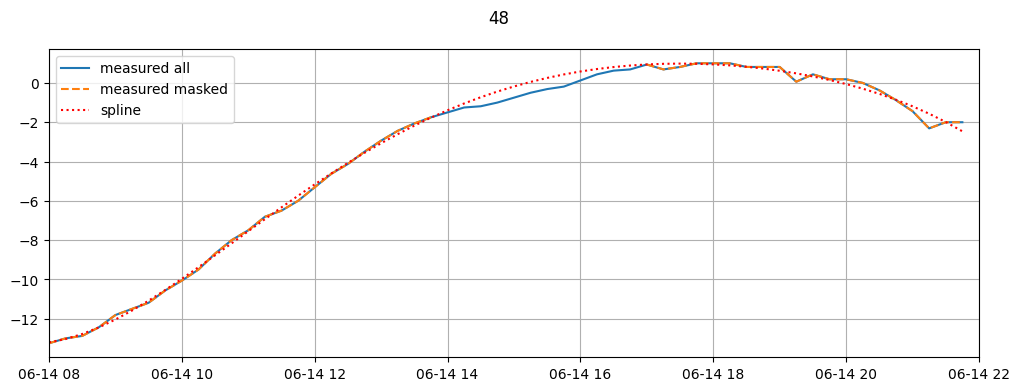

50 (56,)


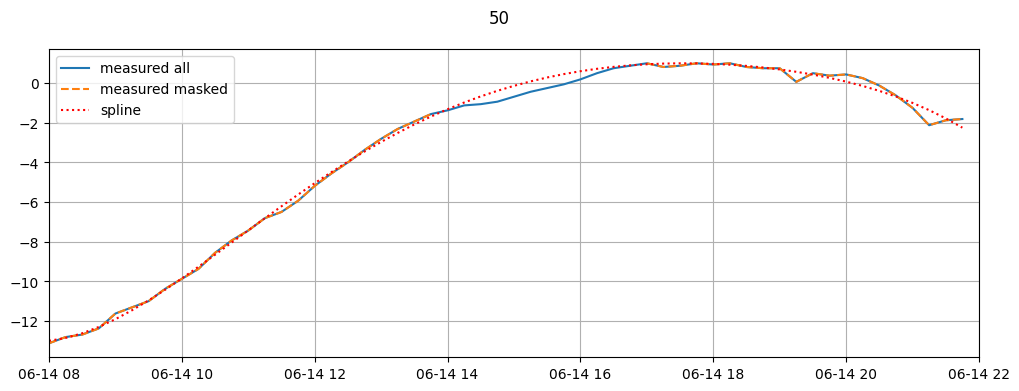

In [198]:
# loop over depths to see how well smoothed spline works
for d in range(-10,51,2):
    
    depth_idx = np.where(bottom_depths==d)[0]
    test_temp_level_day = np.squeeze(bottom_temps.copy()[simb_time_idx[0],:][:,depth_idx])
    print(d, test_temp_level_day.shape)
    masked_test_data = np.ma.masked_where((test_day_dates>=st_mask)&(test_day_dates<en_mask), test_temp_level_day)

    t, c, k = interpolate.splrep(test_day_seconds[~masked_test_data.mask], 
                                 test_temp_level_day[~masked_test_data.mask], k=5, s=3)
    spline = interpolate.BSpline(t, c, k, extrapolate=True)
    outdata = spline(test_day_seconds)

    fig, ax = plt.subplots(1, figsize=(12,4))
    plt.plot(test_day_dates, test_temp_level_day, label='measured all' )
    plt.plot(test_day_dates, masked_test_data, label='measured masked', ls='--' )
    plt.plot(test_day_dates, outdata, label='spline', ls=':', c='r' )
    plt.legend(loc='best')
    plt.xlim(t1, t2)
    plt.grid()
    fig.suptitle(d)
    plt.show()

How about (multiple?) linear regression between temp at a level and skin temp, SW?

In [110]:
# need SLEIGH measurements to have same timesteps
sleigh_seconds = datetimes_to_seconds(sleigh_dates)
simba_seconds = datetimes_to_seconds(bottom_dates)

skin_t_simba_steps = interpolate_and_mask(sleigh_skin_temp, sleigh_seconds, simba_seconds)
swd_simba_steps = interpolate_and_mask(asfs_data_lev2['down_short_hemisp'], sleigh_seconds, simba_seconds)
swn_simba_steps = interpolate_and_mask(asfs_data_lev2['net_short_hemisp'], sleigh_seconds, simba_seconds)


In [99]:
print(test_temp_level_day.shape, np.shape(skin_t_simba_steps[simb_time_idx]))

(96,) (96,)


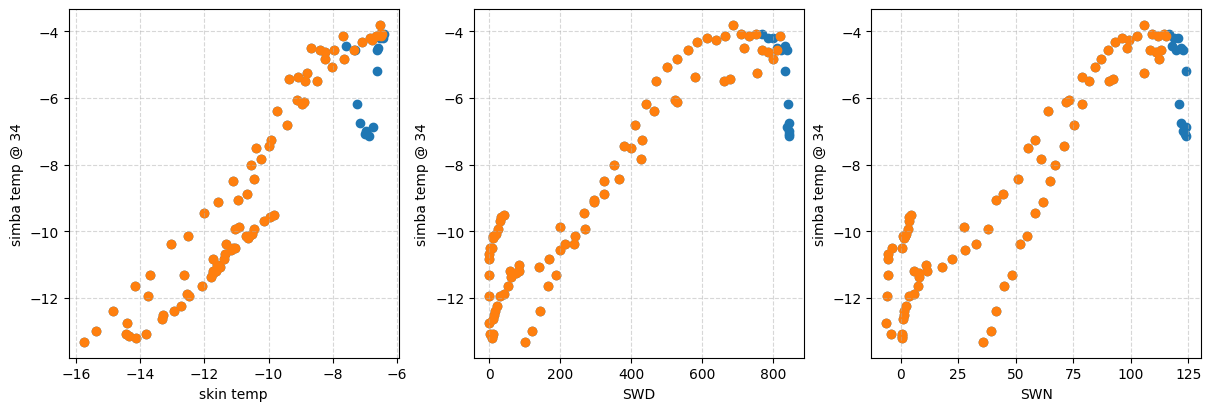

In [120]:
fig, axs = plt.subplots(1,3, figsize=(12,4), constrained_layout=True)

xlabels = ['skin temp', 'SWD', 'SWN']
for i, (ax, data) in enumerate(zip(axs.ravel(),[skin_t_simba_steps, swd_simba_steps, swn_simba_steps])):
    ax.scatter(data[simb_time_idx], test_temp_level_day)
    ax.scatter(data[simb_time_idx][~masked_test_data.mask], test_temp_level_day[~masked_test_data.mask])

    ax.grid(alpha=.5, ls='--')
    ax.set_xlabel(xlabels[i])
    ax.set_ylabel(f'simba temp @ {d}')

plt.show()

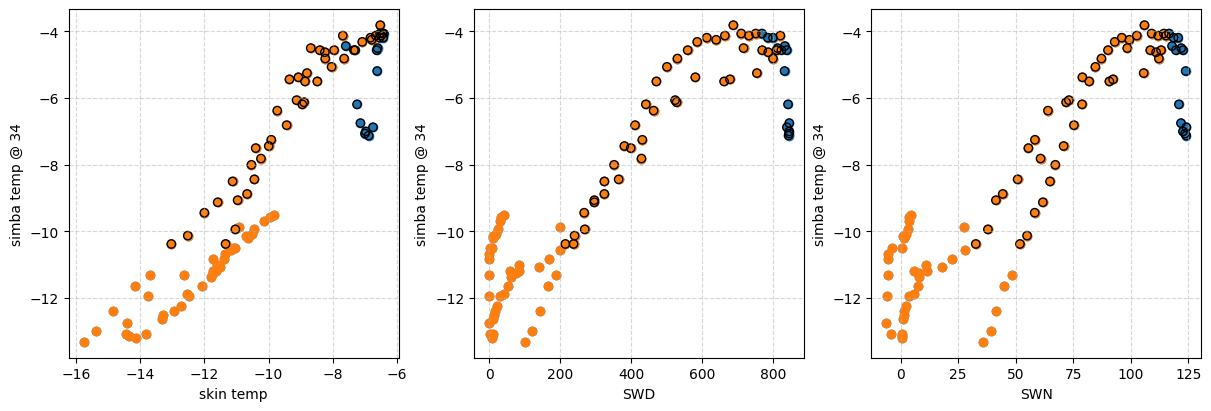

In [126]:
fig, axs = plt.subplots(1,3, figsize=(12,4), constrained_layout=True)

# mask low SWD because there's a pretty linear relationship between temps for part - always true?
masked_low_swd = np.ma.masked_where(swd_simba_steps[simb_time_idx]<200, test_temp_level_day.copy())

xlabels = ['skin temp', 'SWD', 'SWN']
for i, (ax, data) in enumerate(zip(axs.ravel(),[skin_t_simba_steps, swd_simba_steps, swn_simba_steps])):
    ax.scatter(data[simb_time_idx], test_temp_level_day)
    ax.scatter(data[simb_time_idx][~masked_test_data.mask], test_temp_level_day[~masked_test_data.mask])
    ax.scatter(data[simb_time_idx][~masked_low_swd.mask], test_temp_level_day[~masked_low_swd.mask], 
               facecolor="None", edgecolor='k')

    ax.grid(alpha=.5, ls='--')
    ax.set_xlabel(xlabels[i])
    ax.set_ylabel(f'simba temp @ {d}')




plt.show()

loop through different levels, and maybe different days, to see if this works?
should test regression first?

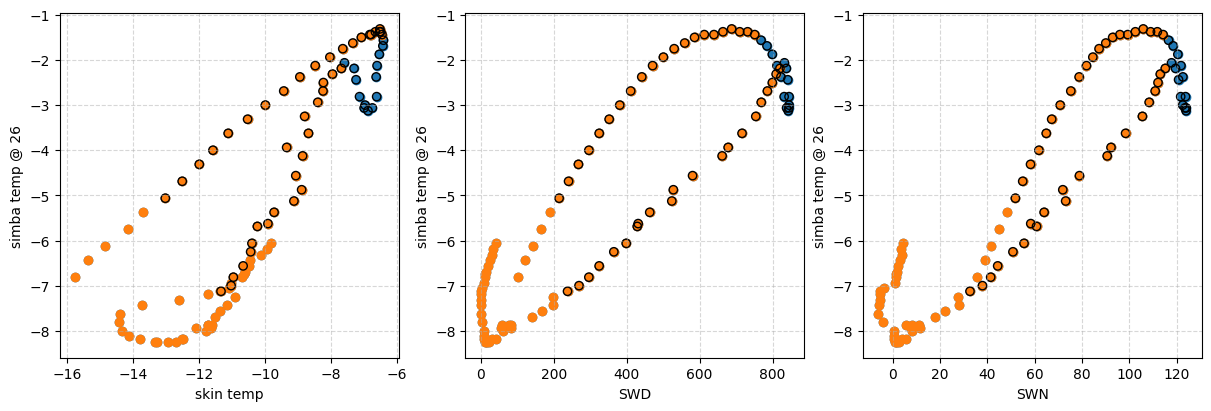

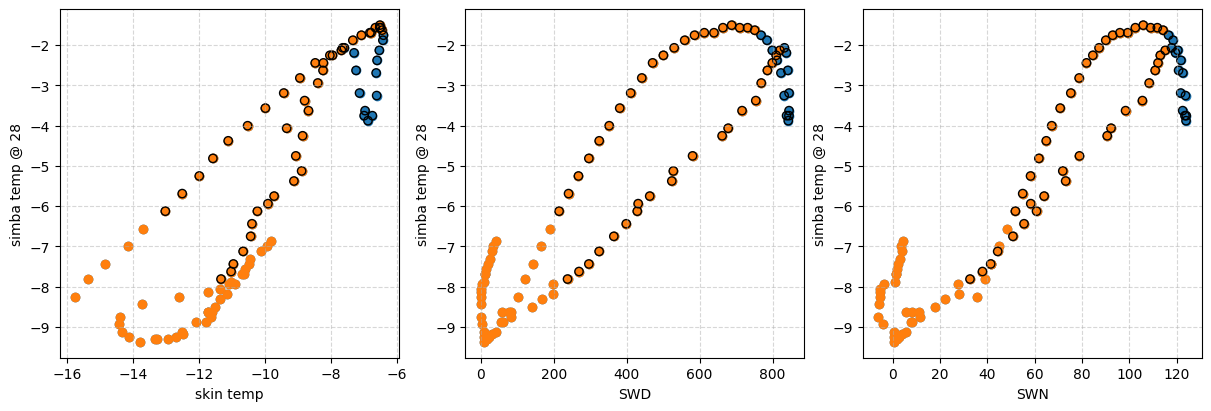

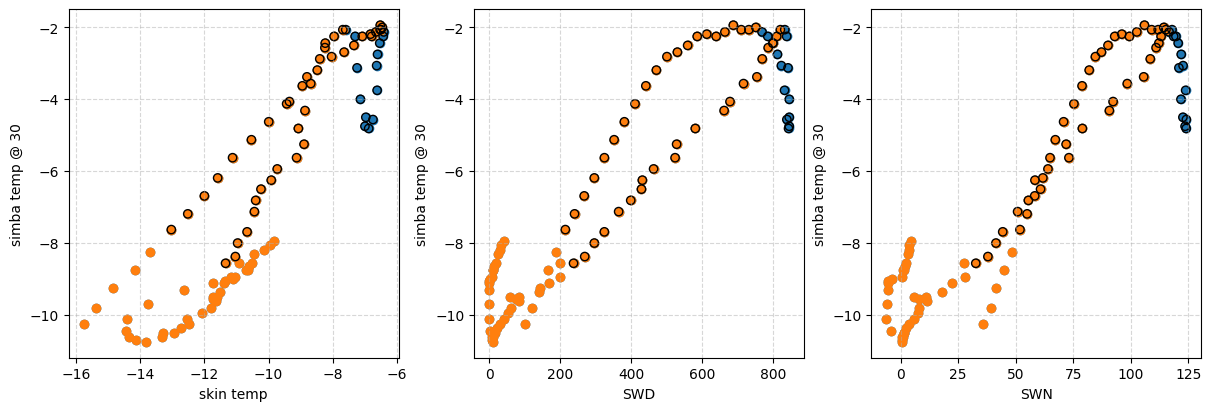

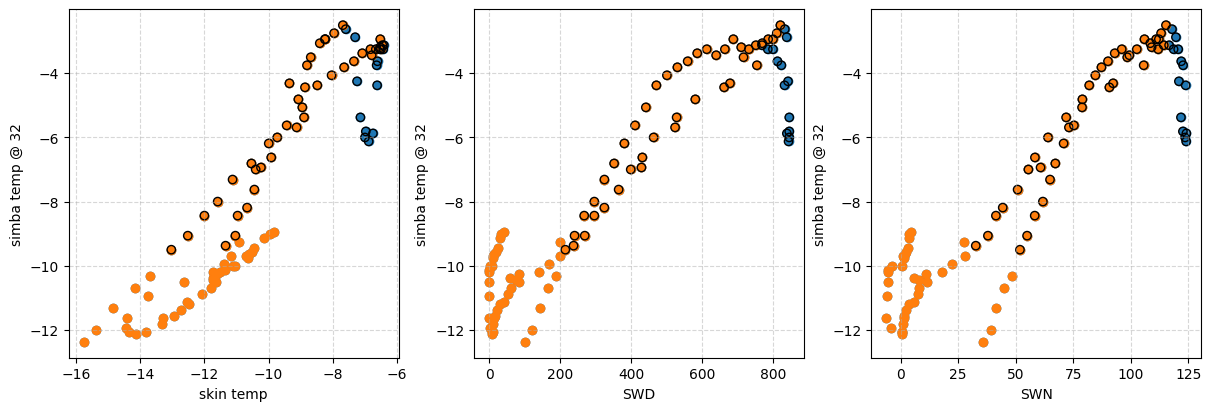

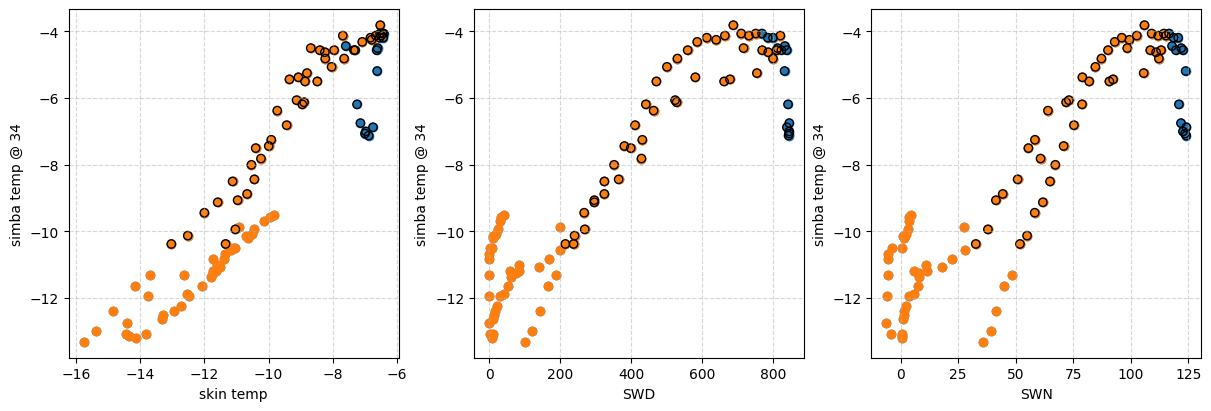

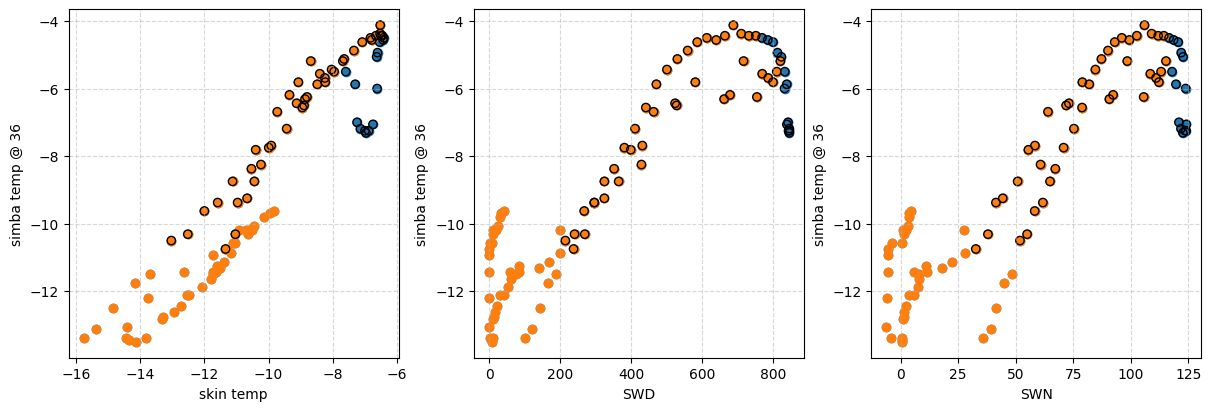

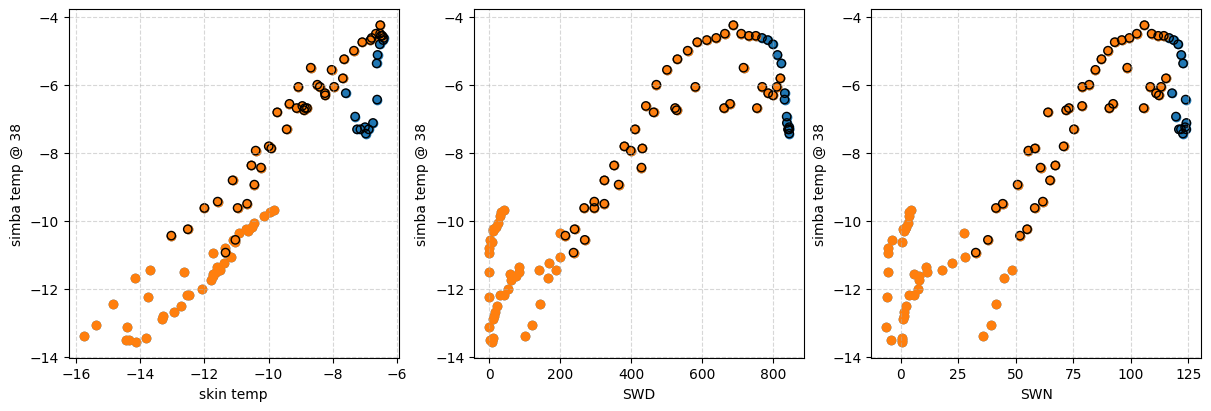

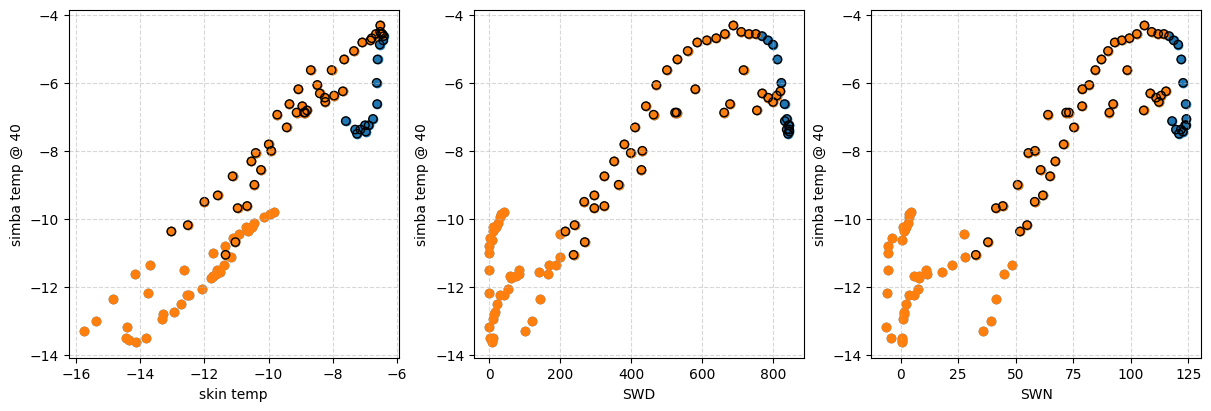

In [128]:
xlabels = ['skin temp', 'SWD', 'SWN']


for d in range(26,41,2):
    
    depth_idx = np.where(bottom_depths==d)[0]
    test_temp_level_day = np.squeeze(bottom_temps[simb_time_idx[0],:][:,depth_idx])


    fig, axs = plt.subplots(1,3, figsize=(12,4), constrained_layout=True)
    
    
    
    for i, (ax, data) in enumerate(zip(axs.ravel(),[skin_t_simba_steps, swd_simba_steps, swn_simba_steps])):
        ax.scatter(data[simb_time_idx], test_temp_level_day)
        ax.scatter(data[simb_time_idx][~masked_test_data.mask], test_temp_level_day[~masked_test_data.mask])
        ax.scatter(data[simb_time_idx][~masked_low_swd.mask], test_temp_level_day[~masked_low_swd.mask], 
                   facecolor="None", edgecolor='k')
    
        ax.grid(alpha=.5, ls='--')
        ax.set_xlabel(xlabels[i])
        ax.set_ylabel(f'simba temp @ {d}')
    
    
    plt.show()